# Задача 1.1 - Общее решение системы линейных уравнений

---

## 1. Условие

Найти общее решение системы линейных уравнений:

$$
\begin{cases}
x_1 + 5x_2 - 2x_3 = -7,\\
-3x_1 + x_2 + 9x_3 - 5x_4 = 9,\\
4x_1 - 8x_2 - x_3 + 7x_4 = 0.
\end{cases}
$$

---

## 2. Теоретическая часть

### Метод Жордана–Гаусса
Для нахождения общего решения используется **метод Жордана–Гаусса**. Его результатом является приведённая ступенчатая форма матрицы (**RREF**, Reduced Row Echelon Form).
### RREF

rref расшифровывается как Reduced Row Echelon Form (приведенный ступенчатый вид). Это результат выполнения метода Гаусса-Жордана, при котором матрица приводится к такому виду, что:

1. Ступенчатый вид: Все нулевые строки находятся внизу, а первая ненулевая цифра каждой строки (ведущий элемент") находится правее ведущего элемента строки выше.
2. Уникальность ведущих элементов: Каждый ведущий элемент равен 1.
3. Исключительность: В каждом столбце, где находится ведущий элемент, все остальные элементы (выше и ниже него) равны 0.

Запись системы линейных уравнений вида (например):
$$
\begin{cases}
a₁x + b₁y + c₁z = d₁,\\
a₂x + b₂y + c₂z = d₂,\\
a₃x + b₃y + c₃z = d₃.
\end{cases}
$$
В решении затем расширяем матрицу в вид:
[
\begin{array}{ccc|c}
a_1 & b_1 & c_1 & d_1 \\
a_2 & b_2 & c_2 & d_2 \\
a_3 & b_3 & c_3 & d_3
\end{array}





> В Python для точных символьных вычислений удобно использовать `sympy`, а метод `rref()` возвращает RREF и номера ведущих столбцов.

---

## 3. Решение


In [10]:
import sympy as sp
from sympy import init_printing
# Функция, делающая красивый вывод матриц
init_printing()

# Матрица коэффициентов системы
A = sp.Matrix([
    [1,  5, -2,  0],
    [-3, 1,  9, -5],
    [4, -8, -1,  7]
])

# Столбец свободных членов
b = sp.Matrix([-7, 9, 0])

# Расширенная матрица
Ab = A.row_join(b)

# RREF расширенной матрицы
rref_matrix, lead_columns = Ab.rref()

display(rref_matrix)
print("Индексы ведущих столбцов:", lead_columns)


⎡1  0  0  8/7   -11/7⎤
⎢                    ⎥
⎢0  1  0  -2/7  -6/7 ⎥
⎢                    ⎥
⎣0  0  1  -1/7   4/7 ⎦

Индексы ведущих столбцов: (0, 1, 2)


# Задача 1.2 — RREF и общее решение системы

---

## 1. Условие

$$
\begin{cases}
5x_1 - x_2 + 5x_3 + 9x_4 - 2x_5 = -3,\\
3x_1 + 6x_3 + 9x_4 - x_5 = 4,\\
2x_1 + 4x_3 + 6x_4 - x_5 = 0.
\end{cases}
$$

Найти RREF расширенной матрицы и общее решение системы.

---

## 2. Теоретическая часть

Для нахождения решения используется **метод Жордана–Гаусса**. Расширенная матрица имеет вид $(A \mid b)$. После элементарных преобразований получаем **RREF**.

>

Помимо rref (описан функционал в 1 задаче) используется функция **linsolve** библиотеки SymPy, решает системы линейных уравнений.
Алгоритм работы:
1. Обработка: Принимает расширенную матрицу системы или пару (A, b).
2. Приведение: Выполняет метод исключения Гаусса для приведения матрицы к ступенчатому виду (RREF).
3. Анализ:
    – При единственном решении - возвращает точные значения переменных.
    – При бесконечном множестве решений - параметризует свободные переменные.
    – При отсутствии решений - возвращает пустой набор.

---

## 3. Решение

In [9]:
import sympy as sp
from sympy import init_printing
# Функция, делающая красивый вывод матриц
init_printing()


x = sp.symbols('x1:6') # x1, x2, x3, x4, x5

# Матрица коэффициентов системы
A = sp.Matrix([
    [5, -1, 5, 9, -2],
    [3,  0, 6, 9, -1],
    [2,  0, 4, 6, -1]
])

# Столбец свободных членов
b = sp.Matrix([-3, 4, 0])

# Расширенная матрица
Ab = A.row_join(b)

# RREF расширенной матрицы
rref_matrix, _ = Ab.rref()  # не нужны индексы ведущих столбцов

# Решение системы
solution = sp.linsolve((A, b), x)

# Вывод результатов
display(rref_matrix)
display(solution)


⎡1  0  2  3  0  4⎤
⎢                ⎥
⎢0  1  5  6  0  7⎥
⎢                ⎥
⎣0  0  0  0  1  8⎦

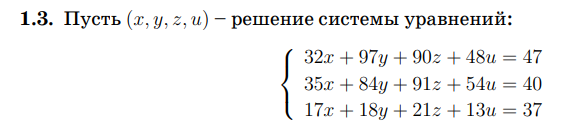
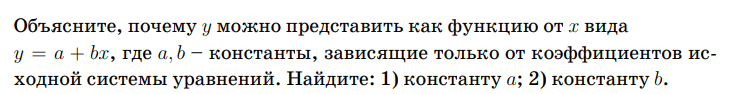

# Теория к задаче 1.3

### 1. Теория систем линейных уравнений (СЛУ)
Система задана в виде трех уравнений с четырьмя неизвестными (x, y, z, u).
В линейной алгебре действует правило: **если число неизвестных (n=4) больше числа уравнений (m=3), то система является недоопределенной**.
Это означает, что:
1.  Система либо несовместна (нет решений).
2.  Либо имеет бесконечно много решений.

В нашем случае система совместна. Бесконечное множество решений можно параметризовать. Это значит, что мы можем выбрать одну или несколько переменных в качестве **свободных (независимых)**, а остальные выразить через них.

---

Если мы выберем x в качестве свободного параметра (то есть x может быть любым числом), то оставшиеся переменные y, z, u будут **базисными**.
Согласно теории линейных пространств, любое частное решение неоднородной системы можно представить как сумму общего решения однородной системы и частного решения неоднородной.
Так как уравнения линейны, любые зависимости между переменными также будут линейными. Следовательно, y будет линейно зависеть от x. Математически это записывается как:
y = a + b * x
где:
*   a — свободный член (константа, не зависящая от x);
*   b — коэффициент наклона (показывает, как изменяется y при изменении x на единицу).

---

Чтобы найти a и b, нужно преобразовать систему так, чтобы x стало «известным» параметром.
Перенесем слагаемые с x в правую часть уравнений:

 \begin{cases} 97y + 90z + 48u = 47 - 32x \\ 84y + 91z + 54u = 40 - 35x \\ 18y + 21z + 13u = 37 - 17x \end{cases}

Теперь это система относительно y, z, u. Мы можем решить её методом Крамера или Гаусса, рассматривая правую часть как числа, зависящие от x.

---

Метод Гаусса (или метод последовательного исключения неизвестных) — это универсальный алгоритм решения систем линейных алгебраических уравнений (СЛАУ), а также нахождения обратной матрицы и вычисления определителя.

Суть метода заключается в приведении исходной системы к ступенчатому (треугольному) виду с помощью элементарных преобразований:

1. Перестановка двух уравнений (строк) местами.
2. Умножение уравнения (строки) на любое ненулевое число.
3. Прибавление к одному уравнению (строке) другого уравнения, умноженного на произвольное число.

---

В результате решения мы получим выражение вида y = a + bx. Коэффициент b — это множитель при x, а a — это число, оставшееся после приведения подобных.

In [1]:
import sympy as sp

# Определяем переменные
x, y, z, u = sp.symbols('x y z u')

# Исходная система
eq1 = sp.Eq(32*x + 97*y + 90*z + 48*u, 47)
eq2 = sp.Eq(35*x + 84*y + 91*z + 54*u, 40)
eq3 = sp.Eq(17*x + 18*y + 21*z + 13*u, 37)

# Переносим x в правую часть (выражаем через x)
# 97y + 90z + 48u = 47 - 32x
# 84y + 91z + 54u = 40 - 35x
# 18y + 21z + 13u = 37 - 17x

# Решаем систему относительно y, z, u
sol = sp.solve([eq1, eq2, eq3], [y, z, u], dict=True)[0]

# Получаем выражение для y
y_expr = sol[y]
print(f"Выражение для y: {y_expr}")

# Приводим к виду a + b*x
y_expanded = sp.expand(y_expr)
a = y_expanded.subs(x, 0)
b = y_expanded.coeff(x)

print(f"Константа a = {a}")
print(f"Константа b = {b}")

# Проверка: y = a + b*x
print(f"Проверка: y = {a} + ({b})*x")

Выражение для y: 14027 - 4262*x
Константа a = 14027
Константа b = -4262
Проверка: y = 14027 + (-4262)*x


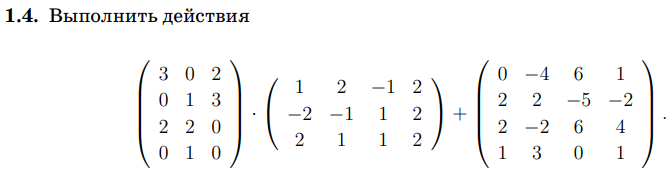

# Теория к задаче 1.4

**Суть задания:** Выполнить действия с матрицами: умножение и сложение.

### 1. Умножение матриц A * B
**Условие согласованности:** Чтобы умножить матрицу A на матрицу B, количество **столбцов** матрицы A должно быть равно количеству **строк** матрицы B.
*   Матрица A имеет размер 4 * 3 (4 строки, 3 столбца).
*   Матрица B имеет размер 3 * 4 (3 строки, 4 столбца).
*   Значит, умножение возможно. Результатом будет матрица размера 4 * 4.

**Формула элемента:** Элемент результирующей матрицы C = A * B вычисляется как скалярное произведение i-й строки матрицы A на j-й столбец матрицы B:

$$ C_{ij} = \sum_{k=1}^{n} A_{ik} B_{kj} = A_{i1}B_{1j} + A_{i2}B_{2j} + \dots + A_{in}B_{nj} $$

То есть, мы берем элементы строки первой матрицы, умножаем их на соответствующие элементы столбца второй матрицы и складываем.

### 2. Сложение матриц B + C
**Условие:** Складывать можно только матрицы **одинаковой размерности**.
Матрица C имеет размер 4 * 4, и результат умножения A * B тоже 4 * 4. Следовательно, операция сложения корректна.
$$ C_{ij} = A_{ij} + B_{ij} $$

In [1]:
import numpy as np

# Матрица A
A = np.array([
    [3, 0, 2],
    [0, 1, 3],
    [2, 2, 0],
    [0, 1, 0]
])

# Матрица B
B = np.array([
    [1, 2, -1, 2],
    [-2, -1, 1, 2],
    [2, 1, 1, 2]
])

# Матрица C
C = np.array([
    [0, -4, 6, 1],
    [2, 2, -5, -2],
    [2, -2, 6, 4],
    [1, 3, 0, 1]
])

# Вычисляем A * B + C
result = A @ B + C

print("Результат A * B + C:")
print(result)

Результат A*B + C:
[[ 7  4  5 11]
 [ 6  4 -1  6]
 [ 0  0  6 12]
 [-1  2  1  3]]


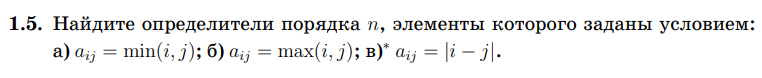

# Теория к задаче 1.5

**Суть задания:** Найти определители матриц специального вида (порядка n).

### 1. Определитель матрицы а)
Матрица выглядит так:
$$ A = \begin{pmatrix} 1 & 1 & 1 & \dots & 1 \\ 1 & 2 & 2 & \dots & 2 \\ 1 & 2 & 3 & \dots & 3 \\ \vdots & \vdots & \vdots & \ddots & \vdots \\ 1 & 2 & 3 & \dots & n \end{pmatrix}
$$
**Теория:** Если из каждой строки (начиная со второй) вычесть предыдущую строку, матрица примет **треугольный вид** (все элементы ниже главной диагонали станут нулями). Определитель треугольной матрицы равен произведению элементов на главной диагонали.
В данном случае после вычитания строк на диагонали останутся единицы. Определитель равен **1**.

### 2. Определитель матрицы б)
Матрица выглядит так:
$$
 B = \begin{pmatrix} 1 & 2 & 3 & \dots & n \\ 2 & 2 & 3 & \dots & n \\ 3 & 3 & 3 & \dots & n \\ \vdots & \vdots & \vdots & \ddots & \vdots \\ n & n & n & \dots & n \end{pmatrix}
$$
**Теория:** Если из каждой строки вычесть следующую строку (двигаясь снизу вверх), мы получим матрицу, у которой на главной диагонали стоят числа 1, -1, 1, ..., -1, n.
Более строгий вывод: Определитель такой матрицы равен (-1)^(n-1) * n.

### 3. Определитель матрицы в)
Матрица выглядит так:
$$
 C = \begin{pmatrix} 0 & 1 & 2 & 3 & \dots \\ 1 & 0 & 1 & 2 & \dots \\ 2 & 1 & 0 & 1 & \dots \\ 3 & 2 & 1 & 0 & \dots \\ \vdots & \vdots & \vdots & \vdots & \ddots \end{pmatrix}
$$
Для нахождения определителя используется метод выделения главной диагонали или рекуррентные соотношения.
Если вычесть из каждой строки предыдущую, можно заметить закономерность.
$$
 \det(C) = (-1)^{n-1} \cdot 2^{n-2} \cdot (n-1)
$$

In [2]:
import sympy as sp

def calculate_determinants(n):
    # Создаем символьную матрицу n x n
    # Для пункта а
    A = sp.Matrix(n, n, lambda i, j: min(i+1, j+1))
    det_A = A.det()

    # Для пункта б
    B = sp.Matrix(n, n, lambda i, j: max(i+1, j+1))
    det_B = B.det()

    # Для пункта в)
    C = sp.Matrix(n, n, lambda i, j: abs((i+1) - (j+1)))
    det_C = C.det()

    return det_A, det_B, det_C

# Проверим для нескольких n, чтобы найти закономерность
for n in range(1, 10):
    det_a, det_b, det_c = calculate_determinants(n)
    print(f"n = {n}:")
    print(f"  а) det = {det_a}")
    print(f"  б) det = {det_b}")
    print(f"  в) det = {det_c}")

n = 1:
  а) det = 1
  б) det = 1
  в) det = 0
n = 2:
  а) det = 1
  б) det = -2
  в) det = -1
n = 3:
  а) det = 1
  б) det = 3
  в) det = 4
n = 4:
  а) det = 1
  б) det = -4
  в) det = -12
n = 5:
  а) det = 1
  б) det = 5
  в) det = 32
n = 6:
  а) det = 1
  б) det = -6
  в) det = -80
n = 7:
  а) det = 1
  б) det = 7
  в) det = 192
n = 8:
  а) det = 1
  б) det = -8
  в) det = -448
n = 9:
  а) det = 1
  б) det = 9
  в) det = 1024


Исходя из полученных данных, можно выявить закономерность:
$$ а) \det = 1 $$
$$ б) \det = (-1)^{n-1} \cdot n $$
$$ в) \det(C) = (-1)^{n-1} \cdot 2^{n-2} \cdot (n-1) $$

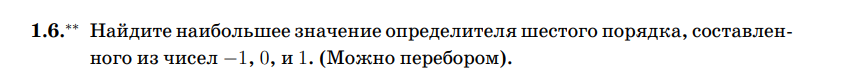

# Формула Уильямсона

Существует точная формула связи между максимальными определителями матриц разных типов. Рассмотрим три множества матриц:

- $Z_{n}$ — множество всех $n \times n$ матриц с элементами из $\{0, 1\}$
- $H_n$ — множество всех $n \times n$ матриц с элементами из $\{-1, 1\}$
- $T_n$ — множество всех $n \times n$ матриц с элементами из $\{-1, 0, 1\}$

## Обозначения

- $a(n) = \max\{\det(M) : M \in Z_n\}$ — максимальный определитель $\{0, 1\}$-матрицы порядка $n$
- $g(n) = \max\{\det(M) : M \in H_n\}$ — максимальный определитель $\{-1, 1\}$-матрицы порядка $n$
- $h(n) = \max\{\det(M) : M \in T_n\}$ — максимальный определитель $\{-1, 0, 1\}$-матрицы порядка $n$

## Формула Уильямсона

$$\boxed{g(n) = 2^{n-1} \cdot a(n-1)}$$

**Теорема (Ehlich, 1964; Brenner & Cummings, 1972):** Добавление нулей к элементам $\{-1, 1\}$ не увеличивает максимальный определитель, то есть $h(n) = g(n)$.

## Таблица максимальных определителей

Для $\{0, 1\}$-матриц:

| $n$ | $a(n)$ |
|-----|--------|
| 0 | 1 |
| 1 | 1 |
| 2 | 1 |
| 3 | 2 |
| 4 | 3 |
| 5 | 5 |

## Проверка для $n = 6$:

1. Из таблицы $\{0, 1\}$-матриц: $a(5) = 5$
2. Применяем формулу: $g(6) = 2^{6-1} \cdot a(5) = 2^5 \cdot 5 = 32 \cdot 5 = 160$
3. Так как $h(6) = g(6)$, получаем: $\max \det = 160$

In [6]:
# Размерности матрица и значение a(5)
n = 6
a_5 = 5
# Формула Уильямсона
print(2 ** (n - 1) * a_5)

160


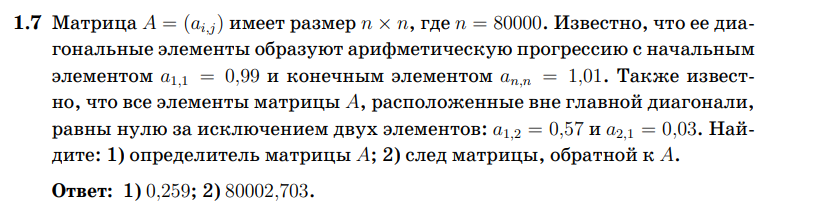

# Решение задачи о матрице специального вида


---

## Основные определения

### Блочно-диагональная матрица

**Блочно-диагональная матрица** — это квадратная матрица, имеющая блочную структуру, где все блоки вне главной диагонали являются нулевыми матрицами.

$$A = \begin{pmatrix}
A_1 & 0 & \cdots & 0 \\
0 & A_2 & \cdots & 0 \\
\vdots & \vdots & \ddots & \vdots \\
0 & 0 & \cdots & A_k
\end{pmatrix}$$

где:
- $A_1, A_2, \ldots, A_k$ — квадратные матрицы (блоки) на главной диагонали
- Все остальные блоки — нулевые матрицы соответствующих размеров

**Ключевое свойство**: Определитель блочно-диагональной матрицы равен произведению определителей её диагональных блоков:

$$\det(A) = \det(A_1) \cdot \det(A_2) \cdot \ldots \cdot \det(A_k)$$

### След матрицы

**След матрицы** (обозначается $\text{tr}(A)$ или $\text{Sp}(A)$) — сумма диагональных элементов квадратной матрицы $A = (a_{ij})$ размера $n \times n$:

$$\text{tr}(A) = \sum_{i=1}^{n} a_{ii} = a_{11} + a_{22} + \ldots + a_{nn}$$

**Основные свойства следа**:
1. Линейность: $\text{tr}(A + B) = \text{tr}(A) + \text{tr}(B)$
2. Инвариантность относительно циклической перестановки: $\text{tr}(AB) = \text{tr}(BA)$
3. След обратной матрицы: $\text{tr}(A^{-1}) = \sum_{i=1}^{n} \frac{1}{\lambda_i}$, где $\lambda_i$ — собственные значения матрицы $A$

---

## Необходимые теоремы и формулы

### 1. Определитель матрицы 2×2

Для матрицы $B = \begin{pmatrix} a & b \\ c & d \end{pmatrix}$:

$$\det(B) = ad - bc$$

### 2. Обратная матрица 2×2

$$B^{-1} = \frac{1}{\det(B)} \begin{pmatrix} d & -b \\ -c & a \end{pmatrix}$$

### 3. След обратной матрицы 2×2

$$\text{tr}(B^{-1}) = \frac{a + d}{\det(B)}$$

### 4. Арифметическая прогрессия

$n$-й член арифметической прогрессии:

$$a_n = a_1 + (n-1)d$$

Разность прогрессии:

$$d = \frac{a_n - a_1}{n-1}$$

### 5. Определитель диагональной матрицы

Для диагональной матрицы $D = \text{diag}(d_1, d_2, \ldots, d_m)$:

$$\det(D) = \prod_{i=1}^{m} d_i$$

### 6. След обратной диагональной матрицы

Для диагональной матрицы $D = \text{diag}(d_1, d_2, \ldots, d_m)$:

$$\text{tr}(D^{-1}) = \sum_{i=1}^{m} \frac{1}{d_i}$$

### 7. Логарифмирование произведения

Для избежания переполнения при вычислении произведения большого числа элементов:

$$\ln\left(\prod_{i=1}^{n} a_i\right) = \sum_{i=1}^{n} \ln(a_i)$$

$$\prod_{i=1}^{n} a_i = \exp\left(\sum_{i=1}^{n} \ln(a_i)\right)$$

---

## Алгоритм решения

### Шаг 1: Анализ структуры матрицы

Дана матрица $A$ размера $n \times n$, где $n = 80000$:

- Диагональные элементы: $a_{ii}$ образуют арифметическую прогрессию
  - $a_{11} = 0.99$
  - $a_{nn} = 1.01$

- Внедиагональные элементы: все равны 0, кроме:
  - $a_{12} = 0.57$
  - $a_{21} = 0.03$

Структура матрицы:

$$A = \begin{pmatrix}
0.99 & 0.57 & 0 & 0 & \cdots & 0 \\
0.03 & a_{22} & 0 & 0 & \cdots & 0 \\
0 & 0 & a_{33} & 0 & \cdots & 0 \\
0 & 0 & 0 & a_{44} & \cdots & 0 \\
\vdots & \vdots & \vdots & \vdots & \ddots & \vdots \\
0 & 0 & 0 & 0 & \cdots & a_{nn}
\end{pmatrix}$$

Это **блочно-диагональная матрица** вида:

$$A = \begin{pmatrix} B & 0 \\ 0 & D \end{pmatrix}$$

где:
- $B = \begin{pmatrix} 0.99 & 0.57 \\ 0.03 & a_{22} \end{pmatrix}$ — блок $2 \times 2$
- $D = \text{diag}(a_{33}, a_{44}, \ldots, a_{nn})$ — диагональная матрица размера $(n-2) \times (n-2)$

### Шаг 2: Вычисление параметров арифметической прогрессии

**Разность прогрессии**:

$$d = \frac{a_{nn} - a_{11}}{n - 1} = \frac{1.01 - 0.99}{80000 - 1} = \frac{0.02}{79999}$$

**Общая формула** для диагональных элементов:

$$a_{ii} = a_{11} + (i-1) \cdot d = 0.99 + (i-1) \cdot \frac{0.02}{79999}$$

**Второй диагональный элемент**:

$$a_{22} = 0.99 + 1 \cdot \frac{0.02}{79999} \approx 0.990000250$$

### Шаг 3: Вычисление определителя матрицы $A$

Используем свойство блочно-диагональной матрицы:

$$\det(A) = \det(B) \cdot \det(D)$$

#### 3.1. Определитель блока $B$:

$$\det(B) = 0.99 \cdot a_{22} - 0.57 \cdot 0.03 = 0.99 \cdot a_{22} - 0.0171$$

#### 3.2. Определитель матрицы $D$:

$$\det(D) = \prod_{i=3}^{n} a_{ii} = \prod_{i=3}^{80000} \left(0.99 + (i-1) \cdot \frac{0.02}{79999}\right)$$

Для вычисления используем логарифмы (избегаем переполнения):

$$\ln(\det(D)) = \sum_{i=3}^{n} \ln(a_{ii})$$

$$\det(D) = \exp\left(\sum_{i=3}^{n} \ln(a_{ii})\right)$$

#### 3.3. Итоговый определитель:

$$\det(A) = \det(B) \cdot \det(D)$$

### Шаг 4: Вычисление следа обратной матрицы $A^{-1}$

Обратная матрица сохраняет блочно-диагональную структуру:

$$A^{-1} = \begin{pmatrix} B^{-1} & 0 \\ 0 & D^{-1} \end{pmatrix}$$

След обратной матрицы:

$$\text{tr}(A^{-1}) = \text{tr}(B^{-1}) + \text{tr}(D^{-1})$$

#### 4.1. След обратной матрицы $B^{-1}$:

$$\text{tr}(B^{-1}) = \frac{0.99 + a_{22}}{\det(B)}$$

#### 4.2. След обратной матрицы $D^{-1}$:

$$\text{tr}(D^{-1}) = \sum_{i=3}^{n} \frac{1}{a_{ii}} = \sum_{i=3}^{80000} \frac{1}{0.99 + (i-1) \cdot \frac{0.02}{79999}}$$

#### 4.3. Итоговый след:

$$\text{tr}(A^{-1}) = \frac{0.99 + a_{22}}{\det(B)} + \sum_{i=3}^{80000} \frac{1}{a_{ii}}$$


In [2]:
import numpy as np
import math

# Параметры задачи
n = 80000
a1 = 0.99
an = 1.01

# Разность арифметической прогрессии
d = (an - a1) / (n - 1)

# Второй диагональный элемент
a22 = a1 + d

# Определитель блока 2x2: det(B) = a11*a22 - a12*a21
det_B = a1 * a22 - 0.57 * 0.03

# Определитель диагональной матрицы D через логарифмы (избегаем переполнения)
log_det_D = sum(math.log(a1 + i * d) for i in range(2, n))
det_D = math.exp(log_det_D)

# Итоговый определитель матрицы A
det_A = det_B * det_D

# След обратной матрицы B: tr(B^-1) = (a11 + a22) / det(B)
tr_B_inv = (a1 + a22) / det_B

# След обратной матрицы D: сумма обратных диагональных элементов
tr_D_inv = sum(1.0 / (a1 + i * d) for i in range(2, n))

# Итоговый след обратной матрицы A
tr_A_inv = tr_B_inv + tr_D_inv

# Вывод результатов
print(f"1) det(A) = {det_A:.3f}")
print(f"2) tr(A^-1) = {tr_A_inv:.3f}")

1) det(A) = 0.259
2) tr(A^-1) = 80002.703


![alt text](image.png)
# Задача 1.8. Обратная матрица для матрицы большого размера

## Теоретическая часть

**1. Структура матрицы $A$**
Матрица $A$ размером $n \times n$ ($n=43000$) имеет специфическую структуру:
* Диагональные элементы $a_{k,k}$ образуют геометрическую прогрессию: $a_{1,1}=1$, $a_{n,n}=1.07$.
* Элементы первой строки $a_{1,k}$ образуют арифметическую прогрессию: $a_{1,1}=1$, $a_{1,n}=1.10$.
* Все остальные внедиагональные элементы равны нулю ($a_{i,j}=0$ при $i>1, i \neq j$).

Таким образом, $A$ — это верхнетреугольная матрица с «заполненной» первой строкой.

**2. Свойства обратной матрицы $B = A^{-1}$**
Обратная матрица к верхнетреугольной также является верхнетреугольной. Из условия $A \cdot B = I$ можно аналитически вывести формулы для элементов $B$:
* **Диагональ:** $b_{k,k} = \frac{1}{a_{k,k}}$
* **Первая строка ($j > 1$):** $b_{1,j} = -\frac{a_{1,j}}{a_{1,1} \cdot a_{j,j}} = -\frac{a_{1,j}}{a_{j,j}}$ (так как $a_{1,1}=1$)
* **Остальные элементы:** $b_{i,j} = 0$ при $i > 1, i < j$.

**3. Формулы прогрессий**
* Геометрическая прогрессия (диагональ): $a_{k,k} = q^{k-1}$, где $q = 1.07^{\frac{1}{n-1}}$.
* Арифметическая прогрессия (первая строка): $a_{1,k} = 1 + d(k-1)$, где $d = \frac{0.10}{n-1}$.

**4. Поиск наименьшего элемента**
Все элементы $b_{1,j}$ отрицательны, а диагональные $b_{k,k}$ положительны. Следовательно, минимум находится в первой строке. 
Функция $f(x) = -\frac{1+dx}{q^x}$ (где $x = k-1$) монотонно убывает на отрезке $[0, n-1]$, так как ее производная отрицательна. Значит, наименьший элемент достигается при $k=n$:
$$b_{1,n} = -\frac{a_{1,n}}{a_{n,n}} = -\frac{1.10}{1.07} \approx -1.028$$

**5. Сумма элементов**
Сумма всех элементов матрицы $B$ складывается из суммы диагонали и суммы первой строки (без $b_{1,1}$, чтобы не дублировать). Для $n=43000$ эти суммы можно вычислить точно с помощью векторизованных операций.

In [3]:
import numpy as np

n = 43000

# 1. Задаем прогрессии
# Диагональ: геометрическая прогрессия от 1 до 1.07
k = np.arange(n)
a_diag = 1.07 ** (k / (n - 1))

# Первая строка: арифметическая прогрессия от 1 до 1.10
a_row1 = 1.0 + 0.10 * (k / (n - 1))

# 2. Формируем ненулевые элементы обратной матрицы B
# Диагональ обратной матрицы
b_diag = 1.0 / a_diag

# Первая строка обратной матрицы (для j > 1)
# b_{1,j} = -a_{1,j} / a_{j,j}
b_row1 = -a_row1[1:] / a_diag[1:]

# 3. Находим наименьший элемент
# Так как функция монотонно убывает, минимум достигается на последнем элементе
min_element = b_row1[-1] 
print(f"1) Наименьший элемент матрицы B: {min_element:.3f}")

# 4. Находим сумму всех элементов матрицы B
# Сумма = сумма диагонали + сумма первой строки (без первого элемента)
total_sum = np.sum(b_diag) + np.sum(b_row1)
print(f"2) Сумма всех элементов матрицы B: {total_sum:.2f}")

1) Наименьший элемент матрицы B: -1.028
2) Сумма всех элементов матрицы B: -2054.44


# Задача 1.9

## 1. Условие


Даны матрицы

$$
I=\begin{pmatrix}1&0\\0&1\end{pmatrix}, \qquad
A=\begin{pmatrix}7\gamma&14\gamma\\9\gamma&\gamma\end{pmatrix},
\qquad \gamma=0.057.
$$

Пусть

$$
S_{m,n}=\sum_{i=m}^{n}A^i, \qquad B_m=(I-A)^{-1}A^m.
$$

Найти:

1. наибольший элемент матрицы $S=S_{4,70}$;
2. наибольший элемент матрицы $B=B_4$;
3. наименьшее $k$, такое, что при любом $n>k$ наибольший элемент матрицы $S_{k,n}$ меньше $0.0002$.


## 2. Теоретическая часть


**Степень матрицы.** Для квадратной матрицы $A$

$$A^m=\underbrace{A\cdot A\cdot\ldots\cdot A}_{m\text{ раз}}.$$

**Сумма степеней матрицы.** Запись

$$S_{m,n}=\sum_{i=m}^{n}A^i$$

означает

$$S_{m,n}=A^m+A^{m+1}+\ldots+A^n.$$

**Обратная матрица.** Матрица $M^{-1}$ называется обратной к $M$, если

$$MM^{-1}=M^{-1}M=I.$$

**Матричная геометрическая прогрессия.** Если все собственные значения матрицы $A$ по модулю меньше 1, то $A^n\to0$, и ряд сходится:

$$I+A+A^2+\ldots=(I-A)^{-1}.$$

Отсюда

$$B_m=(I-A)^{-1}A^m=A^m+A^{m+1}+A^{m+2}+\ldots.$$

В третьем пункте $B_k$ является бесконечным «хвостом» суммы. Поскольку элементы матрицы $A$ неотрицательны, любая конечная сумма $S_{k,n}$ поэлементно не превосходит $B_k$. Поэтому достаточно найти первое $k$, для которого

$$\max(B_k)<0.0002.$$


## 3. Решение

In [ ]:
import numpy as np

def task9():
    # Задаём значение gamma
    gamma = 0.057

    # Исходная матрица A
    A = np.array([
        [7 * gamma, 14 * gamma],
        [9 * gamma, 1 * gamma]
    ])

    # Единичная матрица
    I = np.eye(2)

    # 1. Вычисляем S_(4,70)
    S = sum(np.linalg.matrix_power(A, i) for i in range(4, 71))
    max_S = np.max(S)

    # 2. Вычисляем B_4
    B4 = np.linalg.inv(I - A) @ np.linalg.matrix_power(A, 4)
    max_B4 = np.max(B4)

    #как бы до третьего пункта мы делаем тупо "че вижу, то и прогаю"
    #а затем выбираем минимальный или максимальный вариант из всего этого

    # 3. Ищем минимальное k
    k = 1
    #если прям коротко, то нужно найти после какого k всё
    #последующее будет меньше 0.0002
    #для этого у нас степень должна убывать, а это проверяется собственным значением
    #если результат команды np.linalg.eigvals(A) - это 2 числа, которые по модулю
    #МЕНЬШЕ 1, то у нас матрицы "убывают"

    #а так само решение тоже простое - делаем цикл и счетчик с условием, как перевалило - break и print

    while True:
        Bk = np.linalg.inv(I - A) @ np.linalg.matrix_power(A, k)

        if np.max(Bk) < 0.0002:
            break

        k += 1

    print("1)", round(max_S, 6))
    print("2)", round(max_B4, 6))
    print("3)", k)


## 4. Ответ


1. Наибольший элемент $S_{4,70}$:

$$\boxed{3.609679}$$

2. Наибольший элемент $B_4$:

$$\boxed{3.611175}$$

3. Минимальное значение:

$$\boxed{k=89}$$


# Задача 1.10

## 1. Условие


Дана матрица

$$
M=\begin{pmatrix}
7&5&5&x\\
2&2&6&9\\
3&x&8&0\\
3&1&1&0
\end{pmatrix}.
$$

Записать определитель матрицы $M$ в виде многочлена

$$ax^2+bx+c.$$

В ответе указать:

1. значение коэффициента $a$;
2. значение коэффициента $b$.


## 2. Теоретическая часть


**Определитель** — число (или символьное выражение), которое ставится в соответствие квадратной матрице. Для матрицы $2\times2$

$$
\det\begin{pmatrix}a&b\\c&d\end{pmatrix}=ad-bc.
$$

Для матриц большего порядка определитель можно вычислять, например, **разложением Лапласа** по строке или столбцу. Удобно выбирать строку или столбец, в котором много нулей.

В данной матрице переменная $x$ встречается два раза, поэтому максимальная степень $x$ в определителе — $x^2$. Следовательно, результат можно представить в виде

$$\det M=ax^2+bx+c.$$

Для символьных вычислений используется библиотека **SymPy**: она позволяет хранить $x$ как математический символ, вычислять определитель и выделять коэффициенты многочлена.


## 3. Решение

In [ ]:
import sympy as sp
#используем SYMpy, так как через неё легче работать с буквенными выражениями, а у нас в матрице именно такая ситуация)

def task10():
    x = sp.symbols('x')
    #задаем переменную для х, чтобы использовать её нормально в матрице

    # Задаём матрицу M
    M = sp.Matrix([
        [7, 5, 5, x],
        [2, 2, 6, 9],
        [3, x, 8, 0],
        [3, 1, 1, 0]
    ])

    # Вычисляем и раскрываем определитель
    det_M = sp.expand(M.det())

    # Представляем результат как многочлен от x
    polynomial = sp.Poly(det_M, x)

    # Получаем коэффициенты при x^2 и x
    a = polynomial.coeff_monomial(x ** 2)
    b = polynomial.coeff_monomial(x)

    print("det(M) =", det_M)
    print("a =", a)
    print("b =", b)


## 4. Ответ


Полученный определитель:

$$\det M=16x^2-116x+576.$$

Следовательно,

$$\boxed{a=16}, \qquad \boxed{b=-116}.$$


# Задача 1.11

## 1. Условие


Используя графические возможности Jupyter Notebook, изобразить матрицу размера $n\times n$ для $n=100$, каждая строка которой содержит биномиальные коэффициенты по модулю 2.

Закрашенный **синий** квадратик соответствует 1, **жёлтый** — 0.

Например, для $n=3$:

$$
\begin{pmatrix}
C_1^1&0&0\\
C_2^1&C_2^2&0\\
C_3^1&C_3^2&C_3^3
\end{pmatrix}\pmod 2
=
\begin{pmatrix}
1&0&0\\
0&1&0\\
1&1&1
\end{pmatrix}.
$$


## 2. Теоретическая часть


**Биномиальный коэффициент** вычисляется по формуле

$$
C_n^k=\binom{n}{k}=\frac{n!}{k!(n-k)!}.
$$

В Python значение $C_i^j$ можно получить функцией `comb(i, j)`.

**Взятие по модулю 2** означает, что нас интересует остаток от деления на 2:

$$
C_i^j\bmod2=
\begin{cases}
0, & C_i^j \text{ чётное},\\
1, & C_i^j \text{ нечётное}.
\end{cases}
$$

В строке с номером $i$ нужны коэффициенты $C_i^1,C_i^2,\ldots,C_i^i$, поэтому заполняется только нижняя треугольная часть матрицы. Область выше главной диагонали не относится к вычисляемым коэффициентам и скрывается при визуализации.


## 3. Решение

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from math import comb

def task11():
    # Размер матрицы
    n = 100

    # Создаём матрицу и заполняем её нулями размерами NxN
    # dtype=int говорит NumPy: создай матрицу из целых чисел. по умолчанию создает float
    matrix = np.zeros((n, n), dtype=int)

    # Заполняем нижнюю треугольную часть
    # биномиальными коэффициентами по модулю 2
    # проще говоря: такой вариант позволяет заполнять только нижнюю часть
    # а присваиваем мы значение либо 0, либо 1 (делим i, j на 2 и берем остаток)
    for i in range(1, n + 1):
        for j in range(1, i + 1):
            matrix[i - 1, j - 1] = comb(i, j) % 2

    # Скрываем область выше главной диагонали,
    # чтобы оформление соответствовало примеру из задания
    # нужно это для того, чтобы не смешивать исходные нули (когда создавали матрицу)
    # с вычисленными нулями (которые мы вычислили как остаток от деления в строке 20)
    mask = np.triu(np.ones((n, n), dtype=bool), k=1)
    matrix_for_plot = np.ma.array(matrix, mask=mask)

    # 0 — жёлтый, 1 — синий
    cmap = ListedColormap(["gold", "royalblue"])
    cmap.set_bad("white")

    # Строим изображение матрицы
    plt.figure(figsize=(8, 8))
    plt.imshow(matrix_for_plot, cmap=cmap, interpolation="nearest")

    plt.show()


## 4. Ответ


Построена матрица размера $100\times100$ из значений $C_i^j\bmod2$:

- значение **1** отображается синим цветом;
- значение **0** отображается жёлтым цветом;
- область выше главной диагонали скрыта, так как она не содержит вычисляемых биномиальных коэффициентов.

Результат отображён на графике, сформированном кодом выше.


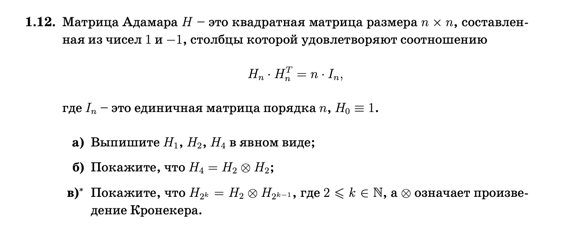

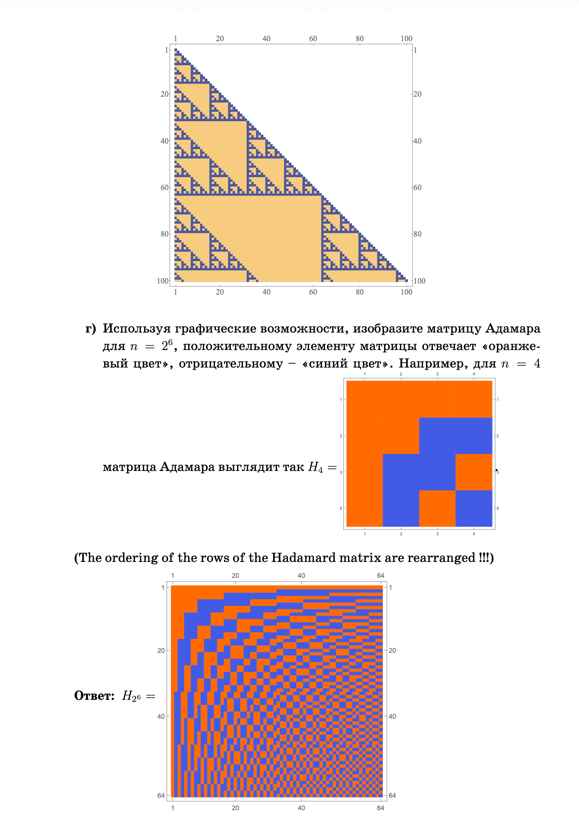
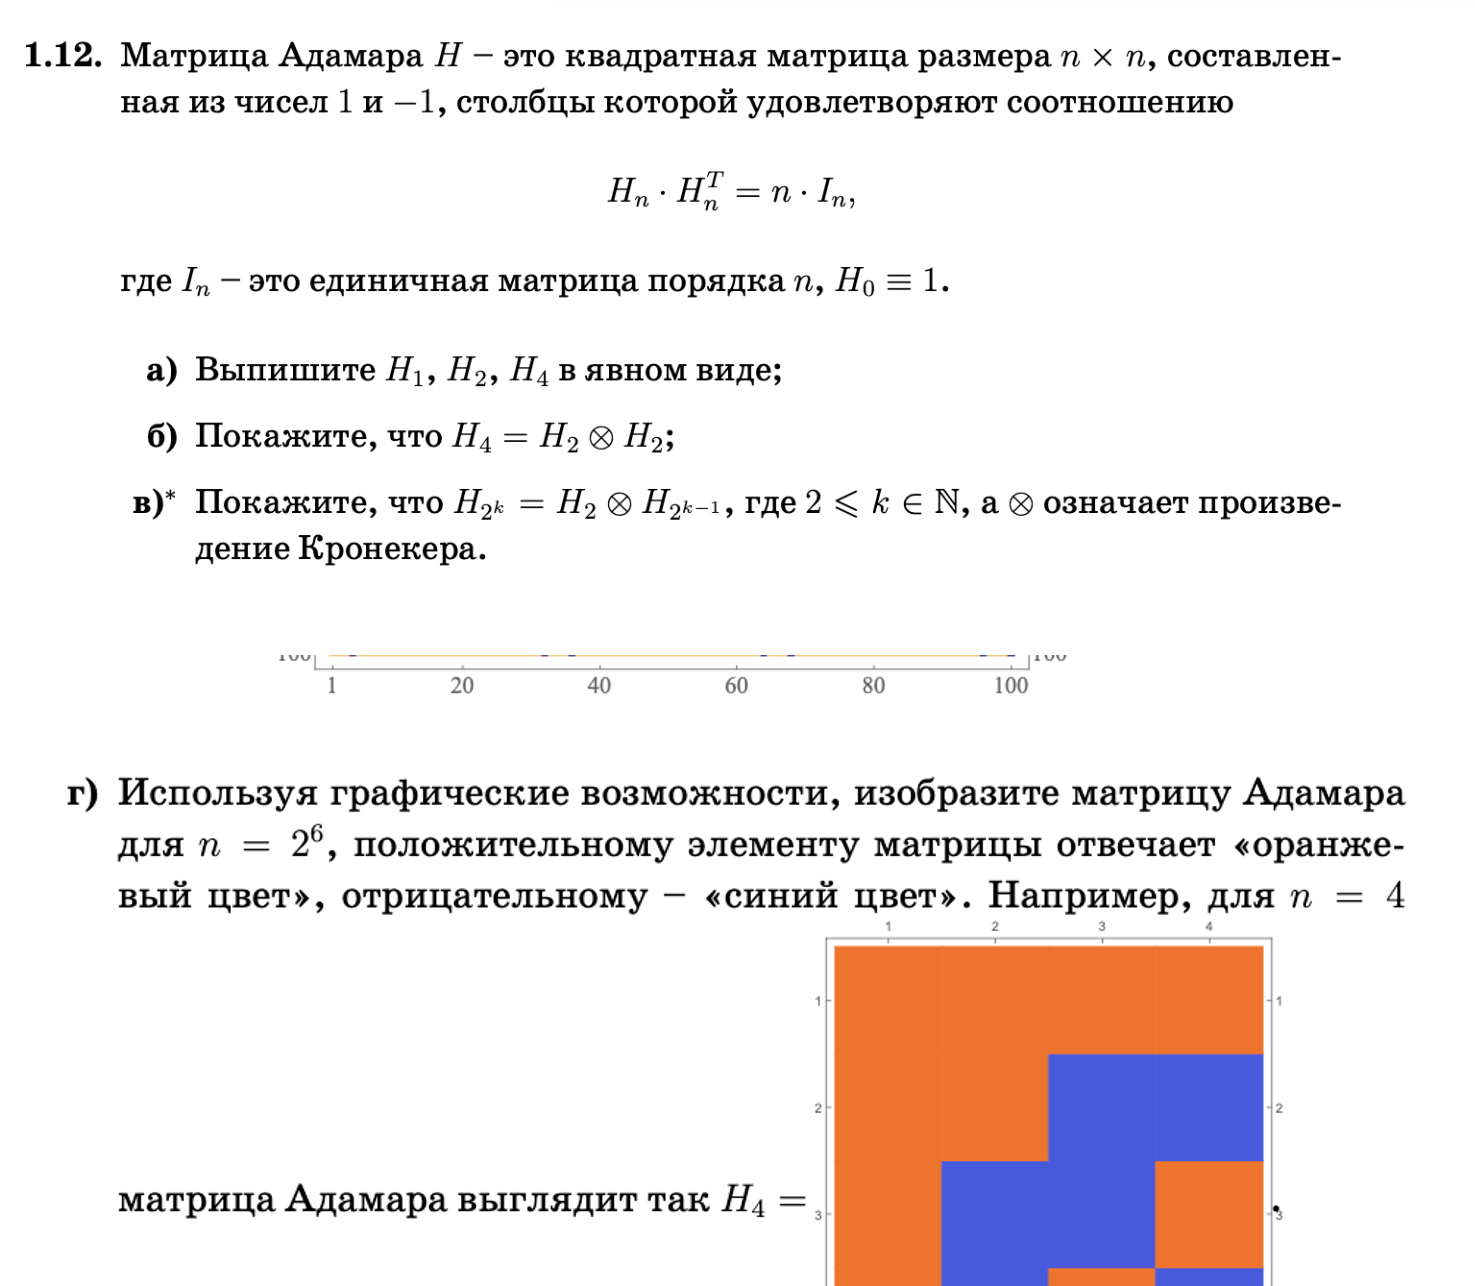


---

## Основные определения

### Матрица Адамара

**Матрица Адамара** $H_n$ — квадратная матрица размера $n\times n$, элементы которой равны только $1$ или $-1$, а строки и столбцы попарно ортогональны.

Для неё выполняется условие

$$
H_nH_n^T=nI_n,
$$

где $H_n^T$ — транспонированная матрица, а $I_n$ — единичная матрица порядка $n$.

Это равенство означает, что скалярное произведение каждой строки самой на себя равно $n$, а скалярное произведение любых двух различных строк равно нулю.

### Транспонированная матрица

**Транспонирование** — операция, при которой строки матрицы становятся столбцами:

$$
(A^T)_{ij}=A_{ji}.
$$

Например,

$$
\begin{pmatrix}
a&b\\
c&d
\end{pmatrix}^T
=
\begin{pmatrix}
a&c\\
b&d
\end{pmatrix}.
$$

### Единичная матрица

**Единичная матрица** $I_n$ — квадратная матрица, у которой на главной диагонали стоят единицы, а остальные элементы равны нулю:

$$
I_2=
\begin{pmatrix}
1&0\\
0&1
\end{pmatrix}.
$$

### Ортогональность

Два вектора называются **ортогональными**, если их скалярное произведение равно нулю.

Например, строки $(1,1)$ и $(1,-1)$ ортогональны:

$$
(1,1)\cdot(1,-1)=1\cdot1+1\cdot(-1)=0.
$$

### Произведение Кронекера

**Произведение Кронекера** $A\otimes B$ строится заменой каждого элемента матрицы $A$ на блок, равный этому элементу, умноженному на всю матрицу $B$.

Если

$$
A=
\begin{pmatrix}
a&b\\
c&d
\end{pmatrix},
$$

то

$$
A\otimes B=
\begin{pmatrix}
aB&bB\\
cB&dB
\end{pmatrix}.
$$

---

## Необходимые формулы

### 1. Условие матрицы Адамара

$$
H_nH_n^T=nI_n.
$$

### 2. Начальные матрицы

Для построения матриц Адамара Сильвестра начинаем с

$$
H_1=(1),
$$

$$
H_2=
\begin{pmatrix}
1&1\\
1&-1
\end{pmatrix}.
$$

### 3. Рекуррентное построение — конструкция Сильвестра

Следующая матрица строится из предыдущей по правилу

$$
H_{2n}=
\begin{pmatrix}
H_n&H_n\\
H_n&-H_n
\end{pmatrix}.
$$

То же самое можно записать через произведение Кронекера:

$$
H_{2n}=H_2\otimes H_n.
$$

---

## Алгоритм решения

### Шаг 1: Выписываем $H_1$, $H_2$ и $H_4$

Имеем

$$
H_1=(1),
$$

$$
H_2=
\begin{pmatrix}
1&1\\
1&-1
\end{pmatrix}.
$$

Для $H_4$ используем рекуррентное построение:

$$
H_4=
\begin{pmatrix}
H_2&H_2\\
H_2&-H_2
\end{pmatrix}
=
\begin{pmatrix}
1&1&1&1\\
1&-1&1&-1\\
1&1&-1&-1\\
1&-1&-1&1
\end{pmatrix}.
$$

### Шаг 2: Показываем, что $H_4=H_2\otimes H_2$

По определению произведения Кронекера

$$
H_2\otimes H_2=
\begin{pmatrix}
1\cdot H_2&1\cdot H_2\\
1\cdot H_2&(-1)\cdot H_2
\end{pmatrix}
=
\begin{pmatrix}
H_2&H_2\\
H_2&-H_2
\end{pmatrix}.
$$

После раскрытия блоков получаем ровно матрицу $H_4$. Следовательно,

$$
\boxed{H_4=H_2\otimes H_2}.
$$

В программе произведение Кронекера вычисляется функцией `np.kron`.

### Шаг 3: Получаем общую рекуррентную формулу

Для матрицы порядка $2^k$ предыдущая матрица имеет порядок $2^{k-1}$. Поэтому

$$
H_{2^k}=
\begin{pmatrix}
H_{2^{k-1}}&H_{2^{k-1}}\\
H_{2^{k-1}}&-H_{2^{k-1}}
\end{pmatrix}.
$$

С другой стороны,

$$
H_2\otimes H_{2^{k-1}}
=
\begin{pmatrix}
1\cdot H_{2^{k-1}}&1\cdot H_{2^{k-1}}\\
1\cdot H_{2^{k-1}}&(-1)\cdot H_{2^{k-1}}
\end{pmatrix}.
$$

Правые части совпадают, поэтому

$$
\boxed{H_{2^k}=H_2\otimes H_{2^{k-1}}}.
$$

### Шаг 4: Строим $H_{2^6}=H_{64}$

Так как $2^6=64$, последовательно применяем рекуррентную формулу:

$$
H_1\rightarrow H_2\rightarrow H_4\rightarrow H_8\rightarrow H_{16}\rightarrow H_{32}\rightarrow H_{64}.
$$

В программе это удобно выполнить циклом: начинаем с $H_1$ и шесть раз применяем `np.kron(H2, H)`.

### Шаг 5: Проверяем полученную матрицу

Для $H_{64}$ должно выполняться определение матрицы Адамара:

$$
H_{64}H_{64}^T=64I_{64}.
$$

В NumPy оператор `@` выполняет матричное умножение, `.T` транспонирует матрицу, а `np.eye(64)` создаёт единичную матрицу $64\times64$.

### Шаг 6: Строим изображение матрицы $H_{64}$ в порядке Сильвестра

В этой работе используем **конструкцию Сильвестра**.

Конструкция Сильвестра — это рекуррентный способ построения матриц Адамара порядков

$$
1,\;2,\;4,\;8,\;16,\ldots,\;2^k.
$$

Начинаем с

$$
H_1=(1),
$$

а каждую следующую матрицу строим по формуле

$$
H_{2n}=
\begin{pmatrix}
H_n&H_n\\
H_n&-H_n
\end{pmatrix}.
$$

Эквивалентно,

$$
H_{2n}=H_2\otimes H_n,
$$

где

$$
H_2=
\begin{pmatrix}
1&1\\
1&-1
\end{pmatrix}.
$$

Такой способ называется **конструкцией Сильвестра**, а полученные матрицы — **матрицами Адамара Сильвестра**.

Для $n=2^6=64$ получаем стандартную матрицу $H_{64}$ в порядке Сильвестра. В условии приведён рисунок с переставленными строками, поэтому визуально он может отличаться. Это не ошибка: перестановка строк сохраняет свойство матрицы Адамара.

В нашей работе строки не переставляем, потому что используем именно стандартное рекуррентное построение Сильвестра.

Для изображения:

- $-1$ обозначаем синим цветом;
- $1$ обозначаем оранжевым цветом.

Для визуализации используем `plt.imshow`.


ОТВЕТ А)
Матрицы H1, H2 и H4:

H1 =
[[1]]

H2 =
[[ 1  1]
 [ 1 -1]]

H4 =
[[ 1  1  1  1]
 [ 1 -1  1 -1]
 [ 1  1 -1 -1]
 [ 1 -1 -1  1]]

ОТВЕТ Б)
Проверяем равенство H4 = H2 ⊗ H2

H2 ⊗ H2 =
[[ 1  1  1  1]
 [ 1 -1  1 -1]
 [ 1  1 -1 -1]
 [ 1 -1 -1  1]]

H4 = H2 ⊗ H2: True

ОТВЕТ В)
Используем конструкцию Сильвестра:
H_(2^k) = H2 ⊗ H_(2^(k-1))

k = 2: H_4 = H2 ⊗ H_2 -> True
k = 3: H_8 = H2 ⊗ H_4 -> True
k = 4: H_16 = H2 ⊗ H_8 -> True
k = 5: H_32 = H2 ⊗ H_16 -> True
k = 6: H_64 = H2 ⊗ H_32 -> True

ОТВЕТ Г)
Строим H_(2^6) = H64 по конструкции Сильвестра.

Размер H64: (64, 64)
Проверка H64 @ H64.T = 64 * I64: True


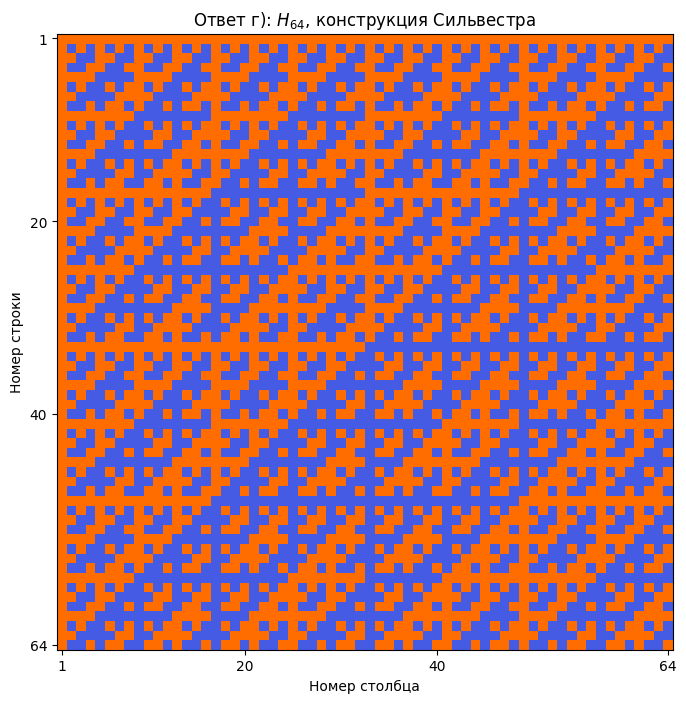

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap


# ============================================================
# ПУНКТ А
# Нужно выписать H1, H2 и H4 в явном виде
# ============================================================

print("ОТВЕТ А)")
print("Матрицы H1, H2 и H4:\n")

# H1 — самая маленькая матрица Адамара.
# Она состоит только из одного элемента 1.
H1 = np.array([[1]])

# H2 — матрица Адамара второго порядка.
# Её элементы равны только 1 и -1.
H2 = np.array([
    [1,  1],
    [1, -1]
])

# H4 — матрица Адамара четвёртого порядка.
# Здесь мы сразу записываем её в явном виде.
# Она построена по конструкции Сильвестра:
# H4 = [[H2,  H2],
#       [H2, -H2]]
H4 = np.array([
    [1,  1,  1,  1],
    [1, -1,  1, -1],
    [1,  1, -1, -1],
    [1, -1, -1,  1]
])

# Выводим все три матрицы, чтобы получить ответ на пункт (а).
print("H1 =")
print(H1)

print("\nH2 =")
print(H2)

print("\nH4 =")
print(H4)


# ============================================================
# ПУНКТ Б
# Нужно показать, что H4 = H2 ⊗ H2
# ============================================================

print("\n" + "=" * 60)
print("ОТВЕТ Б)")
print("Проверяем равенство H4 = H2 ⊗ H2\n")

# np.kron(H2, H2) вычисляет произведение Кронекера H2 ⊗ H2.
#
# Смысл произведения Кронекера здесь такой:
# каждый элемент первой H2 заменяется целым блоком H2,
# умноженным на этот элемент.
#
# То есть:
#
# H2 ⊗ H2 = [[ 1*H2,  1*H2],
#             [ 1*H2, -1*H2]]
#
# Это как раз и даёт матрицу H4.
H4_kron = np.kron(H2, H2)

print("H2 ⊗ H2 =")
print(H4_kron)

# Сравниваем матрицу, полученную через произведение Кронекера,
# с H4, которую мы записали выше вручную.
#
# np.array_equal(A, B) возвращает True,
# если матрицы A и B полностью совпадают.
print("\nH4 = H2 ⊗ H2:", np.array_equal(H4, H4_kron))


# ============================================================
# ПУНКТ В
# Нужно показать общую формулу:
# H_(2^k) = H2 ⊗ H_(2^(k-1))
# ============================================================

print("\n" + "=" * 60)
print("ОТВЕТ В)")
print("Используем конструкцию Сильвестра:")
print("H_(2^k) = H2 ⊗ H_(2^(k-1))\n")


def hadamard_sylvester(k):
    """
    Строит матрицу Адамара Сильвестра H_(2^k).

    Например:
    k = 0 -> H1
    k = 1 -> H2
    k = 2 -> H4
    k = 3 -> H8
    и т.д.
    """

    # Начинаем с H1.
    # Это базовая матрица для рекуррентного построения.
    H = H1.copy()

    # Каждый раз применяем произведение Кронекера H2 ⊗ H.
    #
    # После одного шага:
    # H1 -> H2
    #
    # После двух шагов:
    # H2 -> H4
    #
    # После трёх:
    # H4 -> H8
    #
    # Поэтому после k шагов получаем H_(2^k).
    for _ in range(k):
        H = np.kron(H2, H)

    return H


# Математическое доказательство формулы находится в теоретической части.
# Здесь мы дополнительно проверяем её программно для нескольких k.
#
# Для каждого k:
# left  = H_(2^k)
# right = H2 ⊗ H_(2^(k-1))
#
# Если формула верна, np.array_equal вернёт True.
for k in range(2, 7):
    left = hadamard_sylvester(k)
    right = np.kron(H2, hadamard_sylvester(k - 1))

    print(
        f"k = {k}: "
        f"H_{2**k} = H2 ⊗ H_{2**(k-1)} -> "
        f"{np.array_equal(left, right)}"
    )


# ============================================================
# ПУНКТ Г
# Нужно построить и изобразить матрицу Адамара
# для n = 2^6 = 64
# ============================================================

print("\n" + "=" * 60)
print("ОТВЕТ Г)")
print("Строим H_(2^6) = H64 по конструкции Сильвестра.\n")

# Так как 2^6 = 64, передаём в функцию k = 6.
# В результате получаем матрицу размера 64 x 64.
H64 = hadamard_sylvester(6)

# .shape показывает размер матрицы.
# Ожидаем получить (64, 64).
print("Размер H64:", H64.shape)


# ------------------------------------------------------------
# Проверяем, что построенная H64 действительно является
# матрицей Адамара.
# ------------------------------------------------------------

# По определению для матрицы Адамара должно выполняться:
#
# H64 * H64^T = 64 * I64
#
# где:
# H64.T — транспонированная матрица,
# @      — матричное умножение,
# I64    — единичная матрица размера 64 x 64.

# Создаём единичную матрицу I64.
I64 = np.eye(64, dtype=int)

# Слева вычисляем H64 @ H64.T,
# справа — 64 * I64.
#
# Если обе матрицы совпадают, значит условие Адамара выполнено.
check = np.array_equal(
    H64 @ H64.T,
    64 * I64
)

print("Проверка H64 @ H64.T = 64 * I64:", check)


# ------------------------------------------------------------
# Теперь изображаем H64 цветами.
# ------------------------------------------------------------

# В условии сказано:
# +1 должен быть оранжевым,
# -1 должен быть синим.
#
# ListedColormap создаёт цветовую карту из двух цветов.
# Первый цвет соответствует меньшему значению (-1),
# второй — большему значению (+1).
cmap = ListedColormap(["#455BE3", "#FF6D00"])

# Создаём область для рисунка размером 8 x 8 дюймов.
plt.figure(figsize=(8, 8))

# imshow отображает матрицу как картинку.
# Каждому элементу матрицы соответствует цветная клетка.
#
# vmin=-1 и vmax=1 задают диапазон значений.
# interpolation="nearest" нужен, чтобы клетки были чёткими,
# без размытия между соседними элементами.
# aspect="equal" делает клетки квадратными.
plt.imshow(
    H64,
    cmap=cmap,
    vmin=-1,
    vmax=1,
    interpolation="nearest",
    aspect="equal"
)

# Подписываем рисунок и оси.
plt.title(r"Ответ г): $H_{64}$, конструкция Сильвестра")
plt.xlabel("Номер столбца")
plt.ylabel("Номер строки")

# В Python индексация начинается с 0,
# но на рисунке хотим показывать обычную нумерацию от 1 до 64.
#
# Поэтому позициям 0, 19, 39, 63
# ставим подписи 1, 20, 40, 64.
plt.xticks([0, 19, 39, 63], [1, 20, 40, 64])
plt.yticks([0, 19, 39, 63], [1, 20, 40, 64])

# Показываем готовое изображение матрицы H64.
plt.show()


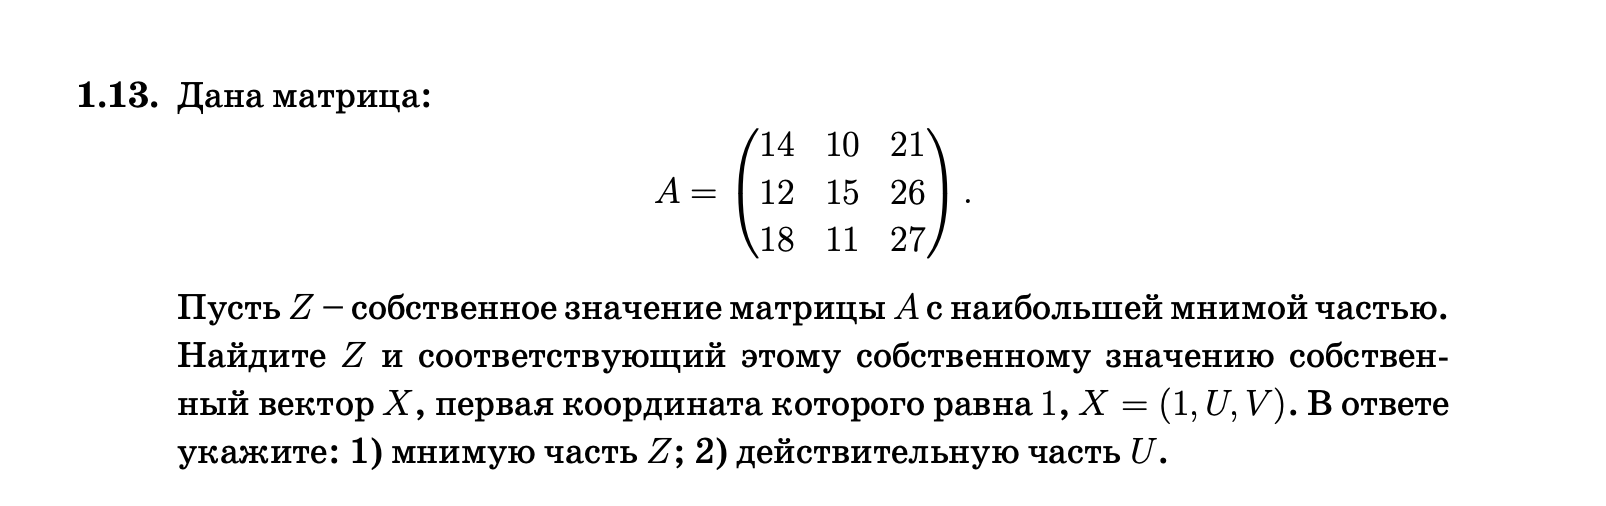


---

## Основные определения

### Собственное значение

Число $\lambda$ называется **собственным значением** квадратной матрицы $A$, если существует ненулевой вектор $X$, для которого

$$
AX=\lambda X.
$$

То есть при умножении собственного вектора на матрицу результат отличается от исходного вектора только умножением на число $\lambda$.

### Собственный вектор

Ненулевой вектор $X$, удовлетворяющий равенству

$$
AX=\lambda X,
$$

называется **собственным вектором**, соответствующим собственному значению $\lambda$.

Одному собственному значению соответствует не единственный вектор: если $X$ — собственный вектор, то $cX$, где $c\neq0$, также является собственным вектором.

### Комплексное число

Комплексное число имеет вид

$$
z=a+bi,
$$

где:

- $a=\operatorname{Re}(z)$ — действительная часть;
- $b=\operatorname{Im}(z)$ — мнимая часть;
- $i$ — мнимая единица, $i^2=-1$.

Если матрица вещественная, её комплексные собственные значения возникают сопряжёнными парами:

$$
a+bi,\qquad a-bi.
$$

### Нормировка собственного вектора

Так как собственный вектор можно умножать на любое ненулевое число, его можно привести к удобному виду.

Если

$$
X=
\begin{pmatrix}
x_1\\x_2\\x_3
\end{pmatrix},
\qquad x_1\neq0,
$$

то разделим все координаты на $x_1$:

$$
\frac{X}{x_1}=
\begin{pmatrix}
1\\
x_2/x_1\\
x_3/x_1
\end{pmatrix}
=
\begin{pmatrix}
1\\U\\V
\end{pmatrix}.
$$

Именно такая нормировка требуется в условии задачи.

---

## Необходимые формулы

### 1. Уравнение для собственного значения и собственного вектора

$$
AX=\lambda X.
$$

Эквивалентная форма:

$$
(A-\lambda I)X=0.
$$

Ненулевое решение существует, когда

$$
\det(A-\lambda I)=0.
$$

Это уравнение называется характеристическим уравнением матрицы.

### 2. Действительная и мнимая части

Для

$$
z=a+bi
$$

имеем

$$
\operatorname{Re}(z)=a,\qquad
\operatorname{Im}(z)=b.
$$

В NumPy эти части доступны как `.real` и `.imag`.

### 3. Проверка найденного собственного вектора

После вычислений результат можно проверить непосредственно по определению:

$$
AX=ZX.
$$

---

## Алгоритм решения

### Шаг 1: Задаём исходную матрицу

Из условия

$$
A=
\begin{pmatrix}
14&10&21\\
12&15&26\\
18&11&27
\end{pmatrix}.
$$

В программе создаём её как двумерный массив NumPy.

### Шаг 2: Находим собственные значения и собственные векторы

Для вычисления используем функцию `np.linalg.eig(A)`.

Она возвращает:

1. массив собственных значений;
2. матрицу собственных векторов.

Важно, что собственные векторы располагаются **по столбцам**. Если `eigenvalues[i]` — некоторое собственное значение, то соответствующий ему собственный вектор находится в `eigenvectors[:, i]`.

Для данной матрицы получаются одно вещественное собственное значение и два комплексно-сопряжённых.

### Шаг 3: Выбираем собственное значение $Z$

По условию требуется не самое большое собственное значение, а значение с **наибольшей мнимой частью**.

Поэтому для каждого найденного $\lambda_i$ рассматриваем

$$
\operatorname{Im}(\lambda_i)
$$

и выбираем максимальное значение.

В программе `eigenvalues.imag` получает массив мнимых частей, а `np.argmax` возвращает индекс максимального элемента.

После этого

$$
Z=\text{eigenvalues[index]}.
$$

### Шаг 4: Выбираем соответствующий собственный вектор

Нельзя независимо выбирать любой собственный вектор. Необходимо взять вектор, соответствующий именно найденному $Z$.

Поэтому используем тот же индекс:

`eigenvectors[:, index]`.

Пусть полученный вектор равен

$$
X_0=(x_1,x_2,x_3).
$$

### Шаг 5: Приводим вектор к виду $X=(1,U,V)$

По условию первая координата должна быть равна $1$.

Так как $x_1\neq0$, делим весь собственный вектор на первую координату:

$$
X=\frac{X_0}{x_1}
=
\left(
1,\frac{x_2}{x_1},\frac{x_3}{x_1}
\right).
$$

Тогда

$$
U=\frac{x_2}{x_1},\qquad
V=\frac{x_3}{x_1}.
$$

### Шаг 6: Получаем требуемые части ответа

Из найденного собственного значения берём

$$
\operatorname{Im}(Z),
$$

а из второй координаты нормированного собственного вектора —

$$
\operatorname{Re}(U).
$$

### Шаг 7: Проверяем результат

Для найденных $Z$ и $X$ проверяем

$$
AX=ZX.
$$

При вычислениях с числами с плавающей точкой возможна очень небольшая погрешность, поэтому в программе используется `np.allclose`, а не точное сравнение через `==`.


In [1]:
import numpy as np

# Исходная матрица A
A = np.array([
    [14, 10, 21],
    [12, 15, 26],
    [18, 11, 27]
], dtype=float)

# Находим собственные значения и соответствующие собственные векторы
eigenvalues, eigenvectors = np.linalg.eig(A)

print("Собственные значения:")
print(eigenvalues)

# Получаем мнимые части всех собственных значений
imaginary_parts = eigenvalues.imag

# Находим индекс собственного значения с наибольшей мнимой частью
index = np.argmax(imaginary_parts)

# Выбираем искомое собственное значение Z
Z = eigenvalues[index]

# Берём соответствующий ему собственный вектор:
# собственные векторы в результате np.linalg.eig расположены по столбцам
X = eigenvectors[:, index]

# Нормируем собственный вектор так,
# чтобы его первая координата стала равна 1
X = X / X[0]

# После нормировки X имеет вид (1, U, V)
U = X[1]
V = X[2]

# Проверяем определение собственного вектора: A*X = Z*X
check = np.allclose(A @ X, Z * X)

# Выводим найденные величины
print("\nZ =", Z)
print("X =", X)
print("U =", U)
print("V =", V)
print("\nПроверка A @ X = Z * X:", check)

# Требуемый ответ
print(f"\n1) Im(Z) = {Z.imag:.9f}")
print(f"2) Re(U) = {U.real:.9f}")


Собственные значения:
[52.06231934+0.j          1.96884033+0.34478935j  1.96884033-0.34478935j]

Z = (1.9688403308016453+0.34478934842718756j)
X = [ 1.        -0.j          3.74781973+1.33084677j -2.35758843-0.61731802j]
U = (3.747819729394754+1.3308467741437695j)
V = (-2.357588426816471-0.6173180187147859j)

Проверка A @ X = Z * X: True

1) Im(Z) = 0.344789348
2) Re(U) = 3.747819729


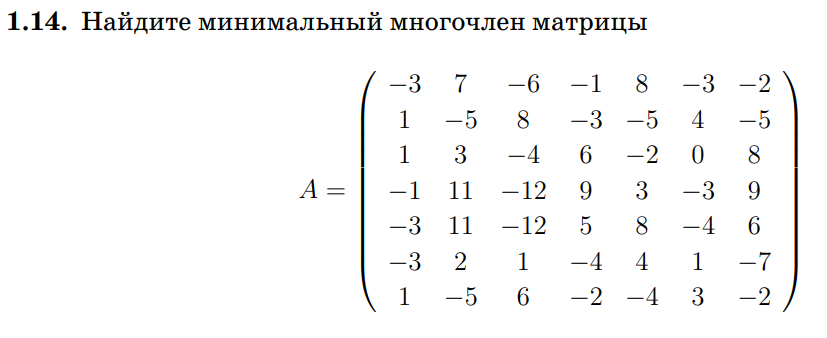

## 1. Характеристический многочлен

### Определение

Пусть $A$ — квадратная матрица размера $n\times n$ над полем $F$. **Характеристический многочлен** матрицы $A$ определяется как

$$
\chi_A(\lambda)=\det(\lambda I-A),
$$

где $I$ — единичная матрица размера $n\times n$.

Эквивалентно (с точностью до множителя $(-1)^n$):

$$
\chi_A(\lambda)=\det(A-\lambda I).
$$


### Основные свойства

- Корни $\chi_A(\lambda)$ — это **собственные значения** матрицы $A$.
- Старший коэффициент равен $1$ (многочлен унитарный).
- Свободный член равен $(-1)^n\det(A)$.


## 2. Минимальный многочлен

### Определение

**Аннулирующий многочлен** матрицы $A$ — многочлен $p(x)$, для которого

$$
p(A)=a_0 I+a_1 A+\cdots+a_k A^k=0.
$$

**Минимальный многочлен** $\mu_A(x)$ — это ненулевой унитарный аннулирующий многочлен наименьшей степени.

### Существование и единственность

- Существование: по теореме Гамильтона–Кэли $\chi_A(A)=0$.
- Единственность: если бы было два унитарных многочлена минимальной степени, их разность имела бы меньшую степень и тоже аннулировала $A$ — противоречие.

### Основные свойства

1. **Делимость.** $\mu_A(x)\mid \chi_A(x)$.

2. **Корни.** Корни $\mu_A(x)$ совпадают с собственными значениями $A$.

5. **Степень.** \(\deg\mu_A\le n\). Равенство достигается тогда и только тогда, когда \(\mu_A=\chi_A\) (такие матрицы называются **циклическими**).

7. **Связь с кратностями.** Каждый множитель $(\lambda-\lambda_i)$ входит в $\mu_A$ со степенью от $1$ до $n_i$ (кратности в $\chi_A$).

### Алгоритм поиска минимального многочлена вручную

1. Найти $\chi_A(\lambda)$.
2. Разложить $\chi_A(\lambda)$ на неприводимые множители:
   $$
   \chi_A(\lambda)=f_1(\lambda)^{n_1}f_2(\lambda)^{n_2}\cdots
   $$
3. Минимальный многочлен имеет вид
   $$
   \mu_A(\lambda)=f_1(\lambda)^{k_1}f_2(\lambda)^{k_2}\cdots,
   \qquad 1\le k_i\le n_i.
   $$
4. Для каждого множителя перебирать $k_i=1,2,\dots,n_i$ и проверять $p(A)=0$, начиная с меньших степеней. Первый подошедший многочлен — минимальный.



## Теорема Гамильтона–Кэли

Для любой квадратной матрицы $A$ над полем $F$ её характеристический многочлен, вычисленный от самой матрицы, равен нулевой матрице:
$$
\chi_A(A)=0.
$$
Иными словами, если
$$
\chi_A(\lambda)=\det(\lambda I-A)
$$

— характеристический многочлен матрицы $A$, то

$$
\chi_A(A)=0.
$$

Следовательно, характеристический многочлен является аннулирующим многочленом матрицы $A$. Поэтому минимальный многочлен $\mu_A(\lambda)$ делит характеристический многочлен:

$$
\mu_A(\lambda)\mid\chi_A(\lambda).
$$

### Следствие

Степень минимального многочлена не превосходит размера матрицы:

$$
\deg\mu_A\leq n,
$$

где $n$ — размер квадратной матрицы $A$.

In [14]:
import sympy as sp
from itertools import product

x = sp.symbols('x')

A = sp.Matrix([
    [-3, 7, -6, -1, 8, -3, -2],
    [1, -5, 8, -3, -5, 4, -5],
    [1, 3, -4, 6, -2, 0, 8],
    [-1, 11, -12, 9, 3, -3, 9],
    [-3, 11, -12, 5, 8, -4, 6],
    [-3, 2, 1, -4, 4, 1, -7],
    [1, -5, 6, -2, -4, 3, -2]
])


# ----------------------------------------
# 1. Характеристический многочлен
# ----------------------------------------

chi = A.charpoly(x).as_expr()

print("Характеристический многочлен:")
print(sp.factor(chi))


# ----------------------------------------
# 2. Минимальный многочлен
# ----------------------------------------

def matrix_polynomial(p, A):
    """
    Вычисляет p(A), где p — многочлен от x.
    Функция нужна для последующей проверки аннулирования матрицы многочленом
    """
    P = sp.Poly(p, x)

    # Нулевая матрица того же размера, что и переданная в функцию
    result = sp.zeros(*A.shape)

    for (power,), coeff in P.terms():
        result += coeff * A**power

    return result


def minimal_polynomial(A):
    """
    Ищет минимальный многочлен перебором делителей характеристического многочлена.
    Использует matrix_polynomial
    """

    chi = A.charpoly(x).as_expr()

    factors = sp.factor_list(chi)[1] # [(x, 3), (x - 1, 4)]

    # Перебираем степени множителей
    ranges = [
        range(1, multiplicity + 1)
        for factor, multiplicity in factors
    ] # [range(1, 4), range(1, 5)]

    candidates = []

    # Создаём список всех кандидатов на минимальный многочлен
    for powers in product(*ranges):

        p = sp.Integer(1)

        for (factor, _), power in zip(factors, powers):
            p *= factor**power

        candidates.append(p)

    # Сортируем по степени
    candidates.sort(key=sp.degree)

    # Ищем первый p, для которого p(A)=0
    for p in candidates:
        if matrix_polynomial(p, A).is_zero_matrix:
            return p


mu = minimal_polynomial(A)

print("\nМинимальный многочлен:")
print(mu)

Характеристический многочлен:
x**3*(x - 1)**4

Минимальный многочлен:
x**3*(x - 1)**2


![alt text](image-1.png)

# Задача 1.15. Собственный ортонормированный базис

## Теоретическая часть

**1. Самосопряженный оператор**
Оператор $\phi$ задан симметричной матрицей $A = A^T$. Для таких операторов в вещественном пространстве справедлива **Спектральная теорема**:
* Все собственные значения $\lambda_i$ являются вещественными числами.
* Собственные векторы, соответствующие *различным* собственным значениям, автоматически ортогональны.
* Матрица оператора всегда может быть диагонализирована с помощью ортогональной матрицы перехода $P$ (состоящей из ортонормированных собственных векторов): $P^T A P = \Lambda$, где $\Lambda$ — диагональная матрица собственных значений.

**2. Алгоритм нахождения базиса**
1. Решаем характеристическое уравнение $\det(A - \lambda I) = 0$ для поиска собственных значений $\lambda_i$.
2. Для каждого $\lambda_i$ решаем систему $(A - \lambda_i I)X = 0$ для поиска собственных векторов.
3. Если собственное значение имеет кратность $>1$ (вырожденное собственное подпространство), выбираем в нем базис и ортогонализируем его (например, методом ортогонализации Грама-Шмидта или просто подбирая ортогональные векторы).
4. Нормируем все полученные векторы (делим на их евклидову длину), чтобы получить *ортонормированный* базис.

**3. Матрица в новом базисе**
В базисе из собственных векторов матрица оператора принимает **диагональный вид**, а на главной диагонали стоят соответствующие собственные значения.

In [9]:
import numpy as np

# Задаем матрицу оператора
A = np.array([
    [17, -8,  4],
    [-8, 17, -4],
    [ 4, -4, 11]
])

print("Исходная матрица A:")
print(A)
print("-" * 40)

# Используем функцию eigh (Eigenvalues Hermitian)
# Она специально предназначена для симметричных/эрмитовых матриц 
# и гарантирует возврат ортонормированных собственных векторов
eigenvalues, eigenvectors = np.linalg.eigh(A)

print("Собственные значения (диагональ новой матрицы):")
print(np.round(eigenvalues, 4))
print("-" * 40)

print("Ортонормированный базис (столбцы матрицы перехода P):")
print(np.round(eigenvectors, 4))
print("-" * 40)

# Формируем матрицу в новом базисе (должна быть диагональной)
# P^T * A * P = Lambda
P = eigenvectors
Lambda = P.T @ A @ P
Lambda_clean = Lambda.copy()
Lambda_clean[np.abs(Lambda_clean) < 1e-10] = 0.0
print("Матрица оператора в новом ортонормированном базисе:")
print(Lambda_clean)

Исходная матрица A:
[[17 -8  4]
 [-8 17 -4]
 [ 4 -4 11]]
----------------------------------------
Собственные значения (диагональ новой матрицы):
[ 9.  9. 27.]
----------------------------------------
Ортонормированный базис (столбцы матрицы перехода P):
[[ 0.7178 -0.2006 -0.6667]
 [ 0.6947  0.2702  0.6667]
 [-0.0464  0.9417 -0.3333]]
----------------------------------------
Матрица оператора в новом ортонормированном базисе:
[[ 9.  0.  0.]
 [ 0.  9.  0.]
 [ 0.  0. 27.]]


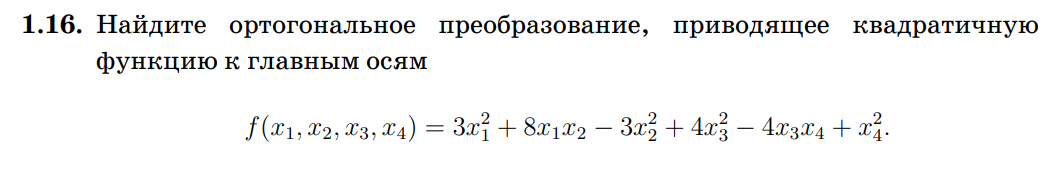

# Теория по ортогональному преобразованию и приведению квадратичной формы к главным осям

# 1. Квадратичная форма

## Определение

Квадратичная форма от $n$ переменных — это выражение вида:

$$
f(x_1,\dots,x_n)=\sum_{i,j=1}^{n}a_{ij}x_ix_j
$$

В матричном виде:

$$
f(x)=x^TAx
$$

где:

- $x$ — столбец переменных:

$$
x=
\begin{pmatrix}
x_1\\
x_2\\
\dots\\
x_n
\end{pmatrix}
$$

- $A$ — симметричная матрица:

$$
A=A^T
$$


Для симметрических матриц выполняется теорема:

> Любая вещественная симметричная матрица может быть приведена к диагональному виду с помощью ортогонального преобразования.


---

# 2. Собственные значения и собственные векторы

Собственный вектор $v$ и собственное значение $\lambda$ определяются уравнением:

$$
Av=\lambda v
$$

где:

- $v$ — собственный вектор;
- $\lambda$ — собственное значение.


Переносим всё в левую часть:

$$
(A-\lambda I)v=0
$$

Чтобы существовало ненулевое решение:

$$
\det(A-\lambda I)=0
$$

Это характеристическое уравнение.


---

# 3. Нахождение собственных значений и собственных векторов

Для поиска собственных значений составляется матрица:

$$
A-\lambda I
$$

Для каждого найденного $\lambda$ решаем:

$$
(A-\lambda I)v=0
$$

---

# 4. Норма и нормировка вектора

Для ортогонального преобразования нужны единичные векторы.

Длина вектора:

$$
||v||=\sqrt{x_1^2+x_2^2+\dots+x_n^2}
$$

Нормировка:

$$
e=\frac{v}{||v||}
$$


---

# 5. Ортогональность векторов

Два вектора называются ортогональными, если их скалярное произведение равно нулю:

$$
u\cdot v=0
$$


Или:

$$
u^Tv=0
$$


---

# 6. Ортогональная матрица

Матрица $P$ называется ортогональной, если:

$$
P^TP=I
$$


Отсюда:

$$
P^{-1}=P^T
$$


Столбцы ортогональной матрицы образуют ортонормированный базис.


---

# 7. Ортогональное преобразование координат

Выполняется замена:

$$
x=Py
$$


где:

- $x$ — старые координаты;
- $y$ — новые координаты;
- $P$ — ортогональная матрица перехода.


Исходная форма:

$$
f=x^TAx
$$


Подставляем:

$$
f=(Py)^TA(Py)
$$


Так как:

$$
(Py)^T=y^TP^T
$$


получаем:

$$
f=y^TP^TAPy
$$


Обозначим:

$$
D=P^TAP
$$


Тогда:

$$
f=y^TDy
$$


---

# 8. Главный вид квадратичной формы

После ортогонального преобразования матрица становится диагональной:

$$
D=
\begin{pmatrix}
\lambda_1&0&\dots&0\\
0&\lambda_2&\dots&0\\
\dots&\dots&\dots&\dots\\
0&0&\dots&\lambda_n
\end{pmatrix}
$$


Квадратичная форма принимает вид:

$$
f=\lambda_1y_1^2+\lambda_2y_2^2+\dots+\lambda_ny_n^2
$$


То есть собственные значения становятся коэффициентами при квадратах новых переменных.



In [25]:
import sympy as sp

# -----------------------------
# 1. Матрица квадратичной формы
# -----------------------------

A = sp.Matrix([
    [3,  4,  0,  0],
    [4, -3,  0,  0],
    [0,  0,  4, -2],
    [0,  0, -2,  1]
])


# -----------------------------
# 2. Собственные значения и векторы
# -----------------------------

eigen = A.eigenvects()

vectors = []
eigenvalues = []

# print("\nСобственные значения и векторы:")

for lam, mult, vecs in eigen:
    # print("\nλ =", lam)

    for v in vecs:
        # print("Собственный вектор:")
        # sp.pprint(v)

        # нормировка вектора
        v_norm = v / sp.sqrt(v.dot(v))

        vectors.append(v_norm)
        eigenvalues.append(lam)


# -----------------------------
# 3. Создание ортогональной матрицы P
# -----------------------------

P = sp.Matrix.hstack(*vectors)

# print("\nОртогональная матрица P:")
# sp.pprint(P)


# -----------------------------
# 4. Проверка ортогональности
# -----------------------------

# print("\nПроверка P^T*P = I:")
#
# check = sp.simplify(P.T * P)
#
# sp.pprint(check)


# -----------------------------
# 5. Получение диагональной матрицы
# -----------------------------

D = sp.simplify(P.T * A * P)

# print("\nДиагональная матрица D = P^T*A*P:")
# sp.pprint(D)


# ----------------------------
# 6. Новый вид квадратичной формы
# ----------------------------

y1, y2, y3, y4 = sp.symbols('y1 y2 y3 y4')

y = sp.Matrix([
    y1,
    y2,
    y3,
    y4
])


f_new = (y.T * D * y)[0]

print("\nКвадратичная форма в новых координатах:")
sp.expand(f_new)


λ = -5
Собственный вектор:
⎡-1/2⎤
⎢    ⎥
⎢ 1  ⎥
⎢    ⎥
⎢ 0  ⎥
⎢    ⎥
⎣ 0  ⎦

λ = 0
Собственный вектор:
⎡ 0 ⎤
⎢   ⎥
⎢ 0 ⎥
⎢   ⎥
⎢1/2⎥
⎢   ⎥
⎣ 1 ⎦

λ = 5
Собственный вектор:
⎡2⎤
⎢ ⎥
⎢1⎥
⎢ ⎥
⎢0⎥
⎢ ⎥
⎣0⎦
Собственный вектор:
⎡0 ⎤
⎢  ⎥
⎢0 ⎥
⎢  ⎥
⎢-2⎥
⎢  ⎥
⎣1 ⎦

Квадратичная форма в новых координатах:


-5*y1**2 + 5*y3**2 + 5*y4**2

# 1.17. Кривые второго порядка

Определить тип кривой второго порядка, её каноническое уравнение и найти каноническую систему координат для заданных уравнений:

a) 
$$
5x^2 + 4xy + 8y^2 - 32x - 56y + 80 = 0
$$
b) 
$$
5x^2 + 12xy - 22x - 12y - 19 = 0
$$

## Математическое объяснение

Общее уравнение кривой второго порядка имеет вид

$$
Ax^2+Bxy+Cy^2+Dx+Ey+F=0.
$$

К основным невырожденным кривым относятся:
* эллипс (частный случай — окружность),
* парабола,
* гипербола.

А также существуют вырожденные кривые, например:
* пара пересекающихся, параллельных или совпадающих прямых,
* одна точка,
* пустое множество.

Для определения типа кривой рассматривается квадратичная часть

$$
Ax^2+Bxy+Cy^2.
$$

Остальные линейные члены

$$
Dx + Ey + F
$$

означают, что начало координат кривой второго порядка пока находится не в центре. **Поэтому сначала надо сдвинуть систему координат под график, чтобы их убрать**.

Чтобы определить тип кривой, необходимо избавиться от *xy*.

Например, обычный эллипс имеет вид

$$ \frac{x^2}{a^2}+\frac{y^2}{b^2}=1, $$

а гипербола:

$$ \frac{x^2}{a^2}-\frac{y^2}{b^2}=1. $$

В этих уравнениях нет *xy*. **Чтобы это сделать, необходимо повернуть систему координат, чтобы убрать *xy*.**

## Для решения таких задач необходимо: 

### 1. Найти центр ненышней кривой.

Для этого из формулы:

$$
Ax^2+Bxy+Cy^2+Dx+Ey+F=0
$$

надо взять отдельно две производные по *x* и *y*. То есть получить следующую систему, которую необходимо решить:

$$ 
\begin{cases} 
2Ax+By+D=0,
\\ 
Bx+2Cy+E=0. 
\end{cases} 
$$

Из неё мы получаем центр ***(x0​,y0​)***.

### 2. Перенести начало координат.

$$ 
X = x - x_0,\qquad Y = y - y_0 
$$

$$ 
x = X + x_0,\qquad y = Y + y_0 
$$

Полученные *x* и *y* необходимо подставить в исходное уравнение. Таким образом получается уравнение без линейных членов, только: 

$$
Ax^2+Bxy+Cy^2 = C_0.
$$

### 3. Избавление от *xy*.

Составляем матрицу: 

$$
\boxed{ 
    Q= \begin{pmatrix} 
        A & B/2
        \\ 
        B/2 & C 
        \end{pmatrix} 
    } 
$$

### Найти собственные значения.

Необходимо решить:

Решить:

$$ 
\boxed{
    \det(Q-\lambda I)=0
    }. 
$$

То есть:

$$ 
\begin{vmatrix} 
    A-\lambda & B/2 
    \\ 
    B/2 & C-\lambda
    \end{vmatrix}   = 0. 
$$

Из данного определителя находим два собственных значения: $\lambda_1$ и $\lambda_2$.

### 4. Определение типа кривой.

Смотрим на знаки собственных значений:

* оба **+** означает эллипс,
* один **+**, один **-** означает гиперболу,
* остальные случае с нулевым собственным значением могут дать параболу.

### 5. Найти собственные векторы.

Необходимо найти направление новых осей. Для каждого $\lambda$:

$$ (Q-\lambda I) \begin{pmatrix} x\\y \end{pmatrix} = \begin{pmatrix} 0\\0 \end{pmatrix}. $$

Получаем направление новой оси. Берём его из первой строчки.

Затем находим длинну вектора по теореме Пифагора.

Затем делим вектор на его длину, чтобы получить единичный:

$$ \vec e = \frac{(x,y)}{d} $$

Оси будут направлены вдоль двух этих взаимно перпендикулярных векторов.


### 6. Получить новые координаты.

Если

$$ \vec e_1=(a,b), $$

то соответствующая координата:

$$ u=\frac{aX+bY}{d_0}. $$

Если

$$ \vec e_2=(c,d), $$

то:

$$ v=\frac{cX+dY}{d_1}. $$

Это и есть тот самый поворот координат.

При этом:

$$ 
X = x-x_0, \qquad Y = y-y_0 
$$

То есть полное преобразование можно записать так: 

$$ 
u = \frac{a(x-x_0) + b(y-y_0)}{d_0} 
$$ 

$$ 
v = \frac{c(x-x_0) + d(y-y_9)}{d_1} 
$$

### 7. Канонический вид.

После поворота получится что-то вроде:

$$ 
\lambda_1u^2+\lambda_2v^2=C. 
$$

Делим на **C** и получаем привычный вид.

## Вычисления для пункта а)

In [38]:
import sympy as sp

x, y = sp.symbols('x y')
X, Y, u, v = sp.symbols('X Y u v')

f_a = 5*x**2 + 4*x*y + 8*y**2 - 32*x - 56*y + 80
Q_a = sp.Matrix([[5, 2], [2, 8]])

center_a = sp.solve([sp.diff(f_a, x), sp.diff(f_a, y)], [x, y])
print('Центр:', center_a)

translated_a = sp.expand(f_a.subs({x: X + center_a[x], y: Y + center_a[y]}))
print('После переноса:')
display(sp.Eq(translated_a, 0))

Центр: {x: 2, y: 3}
После переноса:


Eq(5*X**2 + 4*X*Y + 8*Y**2 - 36, 0)

In [40]:
# Находим собственные значения и проверяем тип кривой
eigenvalues_a = list(Q_a.eigenvals().keys())
print('Собственные значения:', eigenvalues_a)

# Находим собственные векторы и нормируем их
eigenvectors_a = []
for value in eigenvalues_a:
    vector = Q_a.eigenvects()[eigenvalues_a.index(value)][2][0]
    vector = vector / sp.sqrt(vector.dot(vector))
    eigenvectors_a.append(vector)

print('Единичные собственные векторы:')
for vector in eigenvectors_a:
    display(vector)

# Составляем матрицу перехода к каноническим координатам
P_a = sp.Matrix.hstack(*eigenvectors_a)
print('Матрица перехода:')
display(P_a)

# Выражаем старые координаты через новые
XY_a = P_a * sp.Matrix([u, v])
canonical_a = sp.simplify(translated_a.subs({X: XY_a[0], Y: XY_a[1]}))

print('Каноническое уравнение:')
display(sp.Eq(canonical_a, 0))

# Получаем канонический вид автоматически
constant_a = -canonical_a.subs({u: 0, v: 0})
coeff_u_a = sp.expand(canonical_a).coeff(u, 2)
coeff_v_a = sp.expand(canonical_a).coeff(v, 2)
canonical_form_a = sp.Eq(
    u**2 / sp.simplify(constant_a / coeff_u_a) +
    v**2 / sp.simplify(constant_a / coeff_v_a), 1
)

print('Канонический вид:')
display(canonical_form_a)

if all(value > 0 for value in eigenvalues_a):
    curve_type_a = 'эллипс'
elif eigenvalues_a[0] * eigenvalues_a[1] < 0:
    curve_type_a = 'гипербола'
else:
    curve_type_a = 'парабола или вырожденная кривая'

print('Тип кривой:', curve_type_a)

print('Каноническая система координат:')
display(sp.Eq(u, sp.simplify(XY_a[0].subs({X: X, Y: Y}))))
display(sp.Eq(v, sp.simplify(XY_a[1].subs({X: X, Y: Y}))))


Собственные значения: [9, 4]
Единичные собственные векторы:


Matrix([
[-2*sqrt(5)/5],
[   sqrt(5)/5]])

Matrix([
[  sqrt(5)/5],
[2*sqrt(5)/5]])

Матрица перехода:


Matrix([
[-2*sqrt(5)/5,   sqrt(5)/5],
[   sqrt(5)/5, 2*sqrt(5)/5]])

Каноническое уравнение:


Eq(4*u**2 + 9*v**2 - 36, 0)

Канонический вид:


Eq(u**2/9 + v**2/4, 1)

Тип кривой: эллипс
Каноническая система координат:


Eq(u, sqrt(5)*(-2*u + v)/5)

Eq(v, sqrt(5)*(u + 2*v)/5)

## Вычисления для пункта б)

In [41]:
f_b = 5*x**2 + 12*x*y - 22*x - 12*y - 19
Q_b = sp.Matrix([[5, 6], [6, 0]])

center_b = sp.solve([sp.diff(f_b, x), sp.diff(f_b, y)], [x, y])
print('Центр:', center_b)

translated_b = sp.expand(f_b.subs({x: X + center_b[x], y: Y + center_b[y]}))
print('После переноса:')
display(sp.Eq(translated_b, 0))


Центр: {x: 1, y: 1}
После переноса:


Eq(5*X**2 + 12*X*Y - 36, 0)

In [34]:
# Находим собственные значения и проверяем тип кривой
eigenvalues_b = list(Q_b.eigenvals().keys())
print('Собственные значения:', eigenvalues_b)

# Находим собственные векторы и нормируем их
eigenvectors_b = []
for value in eigenvalues_b:
    vector = Q_b.eigenvects()[eigenvalues_b.index(value)][2][0]
    vector = vector / sp.sqrt(vector.dot(vector))
    eigenvectors_b.append(vector)

print('Единичные собственные векторы:')
for vector in eigenvectors_b:
    display(vector)

# Составляем матрицу перехода к каноническим координатам
P_b = sp.Matrix.hstack(*eigenvectors_b)
print('Матрица перехода:')
display(P_b)

# Выражаем старые координаты через новые
XY_b = P_b * sp.Matrix([u, v])
canonical_b = sp.simplify(translated_b.subs({X: XY_b[0], Y: XY_b[1]}))

print('Каноническое уравнение:')
display(sp.Eq(canonical_b, 0))

# Получаем канонический вид автоматически
constant_b = -canonical_b.subs({u: 0, v: 0})
coeff_u_b = sp.expand(canonical_b).coeff(u, 2)
coeff_v_b = sp.expand(canonical_b).coeff(v, 2)
canonical_form_b = sp.Eq(
    u**2 / sp.simplify(constant_b / coeff_u_b) +
    v**2 / sp.simplify(constant_b / coeff_v_b), 1
)

print('Канонический вид:')
display(canonical_form_b)

if eigenvalues_b[0] * eigenvalues_b[1] < 0:
    curve_type_b = 'гипербола'
elif all(value > 0 for value in eigenvalues_b):
    curve_type_b = 'эллипс'
else:
    curve_type_b = 'парабола или вырожденная кривая'

print('Тип кривой:', curve_type_b)

print('Каноническая система координат:')
display(sp.Eq(u, sp.simplify(XY_b[0])))
display(sp.Eq(v, sp.simplify(XY_b[1])))


Собственные значения: [9, -4]
Единичные собственные векторы:


Matrix([
[-2*sqrt(13)/13],
[ 3*sqrt(13)/13]])

Matrix([
[3*sqrt(13)/13],
[2*sqrt(13)/13]])

Матрица перехода:


Matrix([
[-2*sqrt(13)/13, 3*sqrt(13)/13],
[ 3*sqrt(13)/13, 2*sqrt(13)/13]])

Каноническое уравнение:


Eq(-4*u**2 + 9*v**2 - 36, 0)

Канонический вид:


Eq(-u**2/9 + v**2/4, 1)

Тип кривой: гипербола
Каноническая система координат:


Eq(u, sqrt(13)*(-2*u + 3*v)/13)

Eq(v, sqrt(13)*(3*u + 2*v)/13)

# 1.18. Положительно определённая квадратичная форма

Определить, при каких значениях параметра $\lambda$ квадратичная форма

$$
Q(x_1,x_2,x_3)=x_1^2+4x_2^2+x_3^2+2\lambda x_1x_2+10x_1x_3+6x_2x_3
$$

является положительно определённой.

## Математическое объяснение

### Что такое квадратичная форма

Квадратичная форма — это математическое выражение, состоящее из квадратов переменных и произведений переменных:

$$
Q(x_1,\ldots,x_n)=\sum a_{ij}x_ix_j.
$$

Форма называется **положительно определённой**, если для любых чисел $x_1$, $x_2$, $x_3$, кроме случая 

$$ x_1=x_2=x_3=0, $$

результат обязательно положительный:

$$ \boxed{Q(x_1,x_2,x_3)>0}. $$


### Как проверять положительную определённость

Любую квадратичную форму можно записать через матрицу:

$$
Q(x)=x^T A x.
$$

Для формы трёх переменных матрица имеет вид

$$
A=
\begin{pmatrix}
a_{11} & a_{12} & a_{13}\\
a_{12} & a_{22} & a_{23}\\
a_{13} & a_{23} & a_{33}
\end{pmatrix}.
$$

Где первые строка и столбец являются $x_1$, вторые — $x_2$, третьи — $x_3$.

При этом коэффициент при смешанном члене *($2a_{12}x_1x_2$)* делится пополам. Например, $2a_{12}x_1x_2$ даёт в матрице элементы $a_{12}$ и $a_{21}$.

### Критерий Сильвестра

Для симметричной матрицы квадратичная форма положительно определена тогда и только тогда, когда все её главные угловые миноры положительны. Для матрицы $3\times3$ нужно проверить три числа: 

$$
\Delta_1>0,\qquad
\Delta_2>0,\qquad
\Delta_3>0.
$$

Здесь:

$$
\Delta_1=a_{11},
$$

$$
\Delta_2=
\begin{vmatrix}
a_{11}&a_{12}\\
a_{12}&a_{22}
\end{vmatrix},
$$

$$
\Delta_3=\det A.
$$

Поэтому для решения задачи нужно:

1. составить матрицу квадратичной формы;
2. найти $\Delta_1$, $\Delta_2$ и $\Delta_3$;
3. записать условия $\Delta_1>0$, $\Delta_2>0$, $\Delta_3>0$;
4. решить полученные неравенства;
5. взять **пересечение** всех полученных промежутков.

Только те значения $\lambda$, которые одновременно удовлетворяют всем трём условиям, дают положительно определённую квадратичную форму.

## Решение

In [2]:
import sympy as sp
from IPython.display import display, Math

lam = sp.symbols('lambda', real=True)

# Составляем симметричную матрицу квадратичной формы.
A = sp.Matrix([
    [1, lam, 5],
    [lam, 4, 3],
    [5, 3, 1]
])

# Находим главные угловые миноры.
delta1 = sp.factor(A[:1, :1].det())
delta2 = sp.factor(A[:2, :2].det())
delta3 = sp.factor(A.det())

print('Матрица квадратичной формы:')
display(A)

print('Главные угловые миноры:')
display(Math(r'\Delta_1 = ' + sp.latex(delta1)))
display(Math(r'\Delta_2 = ' + sp.latex(delta2)))
display(Math(r'\Delta_3 = ' + sp.latex(delta3)))

# Решаем неравенства критерия Сильвестра.
condition1 = sp.solve_univariate_inequality(delta1 > 0, lam)
condition2 = sp.solve_univariate_inequality(delta2 > 0, lam)
condition3 = sp.solve_univariate_inequality(delta3 > 0, lam)

print('Условия:')
display(Math(r'\Delta_1 > 0: ' + sp.latex(condition1)))
display(Math(r'\Delta_2 > 0: ' + sp.latex(condition2)))
display(Math(r'\Delta_3 > 0: ' + sp.latex(condition3)))

# Находим пересечение всех условий.
common_condition = sp.reduce_inequalities(
    [delta1 > 0, delta2 > 0, delta3 > 0], lam
)

print('Общее условие:')
if common_condition == sp.false:
    display(Math(r'\varnothing'))
else:
    display(Math(sp.latex(common_condition)))

# Формируем ответ на основе вычисленного результата.
if common_condition == sp.false:
    answer = 'Допустимых значений λ нет.'
else:
    answer = sp.latex(common_condition)

print('Ответ:')
if common_condition == sp.false:
    print(answer)
else:
    display(Math(answer))


Матрица квадратичной формы:


Matrix([
[     1, lambda, 5],
[lambda,      4, 3],
[     5,      3, 1]])

Главные угловые миноры:


<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

Условия:


<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

Общее условие:


<IPython.core.display.Math object>

Ответ:
Допустимых значений λ нет.


# Задача 1.19. Отрицательно определённая квадратичная форма

## Условие

При каких значениях параметра $\lambda$ квадратичная форма $Q(x)$ является отрицательно определённой, если
$$Q(x_1, x_2, x_3) = \lambda x_1^2 - 2x_2^2 - 3x_3^2 + 2x_1x_2 - 2x_1x_3 + 2x_2x_3.$$

## Теоретическая часть

### 1. Матрица квадратичной формы

Любой квадратичной форме $Q(x) = \sum_{i,j} a_{ij} x_i x_j$ можно сопоставить симметричную матрицу $A$, где:
- $a_{ii}$ — коэффициент при $x_i^2$,
- $a_{ij} = a_{ji} = \frac{1}{2} \cdot$ (коэффициент при $x_i x_j$ при $i \neq j$).

Тогда $Q(x) = x^T A x$.

### 2. Критерий Сильвестра для отрицательной определённости

**Теорема (Сильвестр).** Квадратичная форма отрицательно определена тогда и только тогда, когда знаки её главных миноров чередуются, начиная с отрицательного:
$$\Delta_1 < 0, \quad \Delta_2 > 0, \quad \Delta_3 < 0, \quad \ldots, \quad \Delta_n \cdot (-1)^n > 0.$$

**Главный минор** $\Delta_k$ — это определитель подматрицы, образованной пересечением первых $k$ строк и первых $k$ столбцов матрицы $A$.

**Почему это работает?** Критерий Сильвестра основан на методе Якоби приведения квадратичной формы к диагональному виду. Если все главные миноры ненулевые, то форма приводится к виду $Q = \frac{\Delta_1}{1} y_1^2 + \frac{\Delta_2}{\Delta_1} y_2^2 + \frac{\Delta_3}{\Delta_2} y_3^2 + \ldots$ Знаки коэффициентов при $y_i^2$ совпадают со знаками отношений $\Delta_k / \Delta_{k-1}$. Для отрицательной определённости все эти коэффициенты должны быть отрицательными, что и даёт условие чередования знаков миноров.

Выписываем коэффициенты:

| Член | Коэффициент $c$ | Куда идёт в матрице |
|------|-----------------|---------------------|
| $x_1^2$ | $\lambda$ | $a_{11} = \lambda$ |
| $x_2^2$ | $-2$ | $a_{22} = -2$ |
| $x_3^2$ | $-3$ | $a_{33} = -3$ |
| $x_1 x_2$ | $2$ | $a_{12} = a_{21} = 2/2 = 1$ |
| $x_1 x_3$ | $-2$ | $a_{13} = a_{31} = -2/2 = -1$ |
| $x_2 x_3$ | $2$ | $a_{23} = a_{32} = 2/2 = 1$ |

Получаем симметричную матрицу:

$$A = \begin{pmatrix} \lambda & 1 & -1 \\ 1 & -2 & 1 \\ -1 & 1 & -3 \end{pmatrix}$$

## Решение

### Шаг 1. Составляем матрицу квадратичной формы

$$A = \begin{pmatrix} \lambda & 1 & -1 \\ 1 & -2 & 1 \\ -1 & 1 & -3 \end{pmatrix}$$

### Шаг 2. Вычисляем главные миноры

- $\Delta_1 = \lambda$
- $\Delta_2 = \begin{vmatrix} \lambda & 1 \\ 1 & -2 \end{vmatrix} = -2\lambda - 1$
- $\Delta_3 = \det(A)$

### Шаг 3. Применяем критерий Сильвестра

Для отрицательной определённости необходимо и достаточно:
$$\Delta_1 < 0, \quad \Delta_2 > 0, \quad \Delta_3 < 0.$$

In [15]:
import numpy as np
import sympy as sp

# Символьное вычисление миноров
lam = sp.Symbol('lambda', real=True)

A_sym = sp.Matrix([
    [lam,  1, -1],
    [  1, -2,  1],
    [ -1,  1, -3]
])

print("Матрица квадратичной формы A:")
sp.pprint(A_sym)

# Главные миноры
Delta1 = A_sym[0, 0]
Delta2 = A_sym[:2, :2].det()
Delta3 = A_sym.det()

print("\nГлавные миноры:")
print(f"Δ₁ = {Delta1}")
print(f"Δ₂ = {sp.expand(Delta2)}")
print(f"Δ₃ = {sp.expand(Delta3)}")

# Решаем неравенства
cond1 = sp.solve_univariate_inequality(Delta1 < 0, lam).as_set().end
cond2 = sp.solve_univariate_inequality(Delta2 > 0, lam).as_set().end
cond3 = sp.solve_univariate_inequality(Delta3 < 0, lam).as_set().end

print("\nУсловия отрицательной определённости (критерий Сильвестра):")
print(f"\tΔ₁ < 0  ->  {cond1}")
print(f"\tΔ₂ > 0  ->  {cond2}")
print(f"\tΔ₃ < 0  ->  {cond3}")

# Пересечение условий (логический анализ: из трёх условий наиболее строгое - то, где правая граница наименьшая)
lowest = min(min(cond1, cond2), cond3)

print(f"\nНаиболее строгое условие: λ < {lowest}")

# Численная проверка
print("\nПри λ = -1 (должна быть отрицательно определённой):")
A1 = np.array([[-1, 1, -1], [1, -2, 1], [-1, 1, -3]], dtype=float)
eig1 = np.linalg.eigvalsh(A1)
print(f"\tСобственные значения: {eig1}")
print(("\tОтрицательно определённая" if np.all(eig1 < 0) else "Иная"))

print("\nПри λ = -0.5 (НЕ должна быть отрицательно определённой):")
A2 = np.array([[-0.5, 1, -1], [1, -2, 1], [-1, 1, -3]], dtype=float)
eig2 = np.linalg.eigvalsh(A2)
print(f"\tСобственные значения: {eig2}")
print(("\tОтрицательно определённая" if np.all(eig2 < 0) else "Иная"))

Матрица квадратичной формы A:
⎡λ   1   -1⎤
⎢          ⎥
⎢1   -2  1 ⎥
⎢          ⎥
⎣-1  1   -3⎦

Главные миноры:
Δ₁ = lambda
Δ₂ = -2*lambda - 1
Δ₃ = 5*lambda + 3

Условия отрицательной определённости (критерий Сильвестра):
	Δ₁ < 0  ->  0
	Δ₂ > 0  ->  -1/2
	Δ₃ < 0  ->  -3/5

Наиболее строгое условие: λ < -3/5

При λ = -1 (должна быть отрицательно определённой):
	Собственные значения: [-4.21431974 -1.46081113 -0.32486913]
	Отрицательно определённая

При λ = -0.5 (НЕ должна быть отрицательно определённой):
	Собственные значения: [-4.14349522 -1.44028741  0.08378263]
Иная


Квадратичная форма отрицательно определена при λ < -3/5 (т.е. λ принадлежит (-inf, -0.6))

---

# Задача 1.20. Эквивалентность квадратичных форм

## Условие

Эквивалентны ли над полем вещественных чисел квадратичные формы $Q_1$ и $Q_2$, где
$$Q_1 = 2x_1^2 + 9x_2^2 + 3x_3^2 + 8x_1x_2 - 4x_1x_3 - 10x_2x_3;$$
$$Q_2 = 2x_1^2 + 3x_2^2 + 6x_3^2 - 4x_1x_2 - 4x_1x_3 + 8x_2x_3.$$

> Почему квадрат второй? Потому что квадратичная форма для трёх неизвестных. Очепятка в задании (надеюсь и верю)

## Теоретическая часть

### 1. Эквивалентность квадратичных форм

Определение. Две квадратичные формы $Q_1$ и $Q_2$ называются эквивалентными над полем $\mathbb{F}$, если существует невырожденное линейное преобразование $x = Cy$ ($\det C \neq 0$), переводящее одну форму в другую: $Q_1(x) = Q_2(Cy)$.

В матричной форме: $A_1 = C^T A_2 C$, где $A_1, A_2$ — матрицы форм, $C$ — невырожденная матрица.

### 2. Закон инерции Сильвестра

**Теорема (Закон инерции Сильвестра).** При любом приведении квадратичной формы к каноническому (диагональному) виду число положительных и число отрицательных коэффициентов остаётся неизменным. Эта пара чисел $(n_+, n_-)$ называется **сигнатурой** формы.

**Следствие.** Две квадратичные формы над полем $\mathbb{R}$ эквивалентны тогда и только тогда, когда они имеют **одинаковую сигнатуру** (одинаковое число положительных и отрицательных квадратов в каноническом виде).

**Почему это работает?** Любая вещественная симметричная матрица диагонализуема ортогональным преобразованием (спектральная теорема). Собственные значения матрицы квадратичной формы определяют знаки коэффициентов в каноническом виде. Поскольку ортогональное преобразование невырождено, сигнатура является инвариантом формы относительно невырожденных замен переменных.

### 3. Алгоритм проверки

1. Составить симметричные матрицы $A_1$ и $A_2$ обеих форм.
2. Найти собственные значения каждой матрицы (они вещественны, так как матрицы симметричны).
3. Посчитать сигнатуры $(n_+, n_-, n_0)$ — количество положительных, отрицательных и нулевых собственных значений.
4. Если сигнатуры совпадают — формы эквивалентны; иначе — нет.

## Решение

### Шаг 1. Матрицы квадратичных форм

$$A_1 = \begin{pmatrix} 2 & 4 & -2 \\ 4 & 9 & -5 \\ -2 & -5 & 3 \end{pmatrix}, \qquad A_2 = \begin{pmatrix} 2 & -2 & -2 \\ -2 & 3 & 4 \\ -2 & 4 & 6 \end{pmatrix}$$

### Шаг 2. Находим собственные значения и сигнатуры

In [ ]:
import numpy as np
import sympy as sp

# Матрицы квадратичных форм
A1 = np.array([
    [ 2,  4, -2],
    [ 4,  9, -5],
    [-2, -5,  3]
], dtype=float)

A2 = np.array([
    [ 2, -2, -2],
    [-2,  3,  4],
    [-2,  4,  6]
], dtype=float)

print("Матрица A₁ формы Q₁:")
print(A1.astype(int))
print("\nМатрица A₂ формы Q₂:")
print(A2.astype(int))

# === ХАРАКТЕРИСТИЧЕСКИЕ ПОЛИНОМЫ (символьные вычисления через SymPy) ===
#
# Характеристический полином матрицы A — это многочлен от λ:
#     p(λ) = det(A - λ·I)
# где I — единичная матрица.
#
# Корни этого полинома (где p(λ) = 0) — это собственные значения матрицы A.
# Мы считаем полином символьно, чтобы увидеть его явный вид (для красоты в отчёте),
# но сами корни находим численно через NumPy — это быстрее и точнее.

lam = sp.Symbol('lambda')                          # создаём символ λ (не число, а переменная)

# Формируем матрицу (A - λ·I):
#   sp.eye(3) — единичная матрица 3×3 (как число 1, но для матриц)
#   lam * sp.eye(3) — это λ·I = diag(λ, λ, λ)
#   sp.Matrix(A1) - lam*sp.eye(3) — вычитаем из A1
#   .det() — считаем определитель этой матрицы → получаем многочлен от λ
char_poly1 = (sp.Matrix(A1) - lam*sp.eye(3)).det()
char_poly2 = (sp.Matrix(A2) - lam*sp.eye(3)).det()

# sp.expand() раскрывает скобки, чтобы полином был в стандартном виде
# (например, превращает (λ-1)(λ-2) в λ² - 3λ + 2)
print("\nQ₁:")
print(f"Характеристический полином: {sp.expand(char_poly1)}")

# === СОБСТВЕННЫЕ ЗНАЧЕНИЯ (численные вычисления через NumPy) ===
#
# np.linalg.eigvalsh(A) находит собственные значения симметричной матрицы A.
# Почему именно eigvalsh, а не eig?
#   - eigvalsh работает ТОЛЬКО с симметричными матрицами (а матрица квадратичной
#     формы всегда симметрична по определению)
#   - он быстрее и надёжнее: не выдаст комплексные числа из-за погрешностей
#   - возвращает только значения (без векторов) — нам векторы не нужны
eig1 = np.linalg.eigvalsh(A1)

# np.sort() сортирует по возрастанию, [::-1] разворачивает → получаем по убыванию
eig1_sorted = np.sort(eig1)[::-1]
print(f"Собственные значения A₁: {eig1_sorted}")

# === ПОДСЧЁТ СИГНАТУРЫ (n₊, n₋, n₀) ===
#
# Почему сравниваем с 1e-10, а не с 0?
#   Компьютер работает с числами с плавающей точкой, и "ноль" может оказаться
#   чем-то вроде 0.0000000001 или -0.0000000001 из-за погрешностей вычислений.
#   Поэтому считаем:
#     - положительным то, что БОЛЬШЕ +10⁻¹⁰
#     - отрицательным то, что МЕНЬШЕ -10⁻¹⁰
#     - нулевым всё, что лежит в интервале [-10⁻¹⁰, +10⁻¹⁰]

n_pos1 = int(np.sum(eig1 > 1e-10))      # количество положительных λ
n_neg1 = int(np.sum(eig1 < -1e-10))     # количество отрицательных λ
n_zero1 = 3 - n_pos1 - n_neg1           # остальные — нулевые (всего 3 значения)
sig1 = (n_pos1, n_neg1, n_zero1)        # сигнатура = тройка (n₊, n₋, n₀)
print(f"Сигнатура Q₁: (n₊={n_pos1}, n₋={n_neg1}, n₀={n_zero1})")

print("\nQ₂:")
print(f"Характеристический полином: {sp.expand(char_poly2)}")
eig2 = np.linalg.eigvalsh(A2)
eig2_sorted = np.sort(eig2)[::-1]
print(f"Собственные значения A₂: {eig2_sorted}")

n_pos2 = int(np.sum(eig2 > 1e-10))
n_neg2 = int(np.sum(eig2 < -1e-10))
n_zero2 = 3 - n_pos2 - n_neg2
sig2 = (n_pos2, n_neg2, n_zero2)
print(f"Сигнатура Q₂: (n₊={n_pos2}, n₋={n_neg2}, n₀={n_zero2})")

# === СРАВНЕНИЕ СИГНАТУР ===
# По закону инерции Сильвестра: формы эквивалентны ⟺ сигнатуры совпадают
print(f"\nСигнатуры совпадают: {sig1} == {sig2}")
if sig1 == sig2:
    print("Формы Q₁ и Q₂ ЭКВИВАЛЕНТНЫ над полем ℝ (по закону инерции Сильвестра).")
else:
    print("Формы Q₁ и Q₂ НЕ эквивалентны.")

Матрица A₁ формы Q₁:
[[ 2  4 -2]
 [ 4  9 -5]
 [-2 -5  3]]

Матрица A₂ формы Q₂:
[[ 2 -2 -2]
 [-2  3  4]
 [-2  4  6]]

Q₁:
Характеристический полином: -lambda**3 + 14.0*lambda**2 - 6.0*lambda
Собственные значения A₁: [ 1.35574385e+01  4.42561476e-01 -1.91443056e-16]
Сигнатура Q₁: (n₊=2, n₋=0, n₀=1)

Q₂:
Характеристический полином: -lambda**3 + 11.0*lambda**2 - 12.0*lambda
Собственные значения A₂: [9.77200187e+00 1.22799813e+00 1.32913689e-15]
Сигнатура Q₂: (n₊=2, n₋=0, n₀=1)

Сигнатуры совпадают: (2, 0, 1) == (2, 0, 1)
Формы Q₁ и Q₂ ЭКВИВАЛЕНТНЫ над полем ℝ (по закону инерции Сильвестра).
